# Experiment 9: Perceptron vs Multilayer Perceptron

English Handwritten Characters (3,410 images, 62 classes). A perceptron (PLA) written from scratch in numpy is compared with a PyTorch MLP whose activation, cost function, optimizer, learning rate, batch size, depth and width are tuned.

In [1]:
%matplotlib inline

In [2]:
import os
import time
import copy
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc)

RNG = 42
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['legend.title_fontsize'] = 15
plt.rcParams['axes.labelweight'] = 'bold'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| torch", torch.__version__)
print("device:", torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu")

summary = []

def log(*parts):
    line = " ".join(str(p) for p in parts)
    print(line)
    summary.append(line)

numpy 2.5.1 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.11.0+cu128
device: NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
EPOCHS = 100
PLA_EPOCHS = 100
GRID_LRS = [0.001, 0.01, 0.1]
GRID_BATCHES = [32, 128, 512]
TOP_K = 6
EXTRA_SEEDS = [1, 2, 3]
FINAL_SEEDS = [42, 1, 2, 3, 4]
PATIENCE = 10

## Loading and cleaning the images

In [4]:
def square_crop(gray, margin=0.1):
    ink = gray < 128
    rows = np.where(ink.any(axis=1))[0]
    cols = np.where(ink.any(axis=0))[0]
    crop = ink[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1].astype("uint8") * 255
    h, w = crop.shape
    side = int(max(h, w) * (1 + 2 * margin))
    canvas = np.zeros((side, side), dtype="uint8")
    top, left = (side - h) // 2, (side - w) // 2
    canvas[top:top + h, left:left + w] = crop
    return canvas, h, w, ink.mean()

def preprocess_image(path, size=32):
    gray = np.array(Image.open(path).convert("L"))
    canvas, h, w, frac = square_crop(gray)
    small = np.array(Image.fromarray(canvas).resize((size, size), Image.LANCZOS))
    return small, h, w, frac

meta = pd.read_csv("english.csv", dtype=str, keep_default_na=False)

if os.path.exists("char_data.npz"):
    d = np.load("char_data.npz")
    X_img, box_h, box_w, ink_frac = d["X_img"], d["box_h"], d["box_w"], d["ink_frac"]
else:
    out = [preprocess_image(p) for p in meta["image"]]
    X_img = np.stack([o[0] for o in out])
    box_h = np.array([o[1] for o in out])
    box_w = np.array([o[2] for o in out])
    ink_frac = np.array([o[3] for o in out])
    np.savez_compressed("char_data.npz", X_img=X_img, box_h=box_h, box_w=box_w, ink_frac=ink_frac)

print("Images:", X_img.shape, X_img.dtype, "| value range:", X_img.min(), "to", X_img.max())
print("Ink box height (px):", box_h.min(), "to", box_h.max(), "| width:", box_w.min(), "to", box_w.max())
print("Missing labels:", int((meta["label"] == "").sum()), "| missing files:", int(sum(not os.path.exists(p) for p in meta["image"])))

Images: (3410, 32, 32) uint8 | value range: 0 to 255
Ink box height (px): 147 to 841 | width: 71 to 751
Missing labels: 0 | missing files: 0


## Labels and the train / validation / test split

In [5]:
classes = sorted(meta["label"].unique())
N_CLASSES = len(classes)
class_to_idx = {c: i for i, c in enumerate(classes)}
y = meta["label"].map(class_to_idx).to_numpy()

def group_of(c):
    if c.isdigit():
        return "Digit"
    return "Uppercase" if c.isupper() else "Lowercase"

groups = np.array([group_of(c) for c in meta["label"]])
class_groups = np.array([group_of(c) for c in classes])
GROUP_ORDER = ["Digit", "Uppercase", "Lowercase"]
GROUP_COLORS = dict(zip(GROUP_ORDER, sns.color_palette("Dark2", 3)))
MODEL_COLORS = {"PLA": "#c44e52", "MLP": "#4c72b0"}
SPLIT_COLORS = {"train": "#55a868", "val": "#8172b3", "test": "#937860"}

X_all = X_img.reshape(len(X_img), -1).astype("float32") / 255.0

idx = np.arange(len(y))
idx_trainval, idx_test = train_test_split(idx, test_size=0.15, stratify=y, random_state=RNG)
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.15 / 0.85, stratify=y[idx_trainval], random_state=RNG)

X_train, y_train = X_all[idx_train], y[idx_train]
X_val, y_val = X_all[idx_val], y[idx_val]
X_test, y_test = X_all[idx_test], y[idx_test]
N_TRAIN = len(y_train)

scaler = StandardScaler().fit(X_train)
X_train_std, X_val_std, X_test_std = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

print("Classes:", N_CLASSES, "|", "".join(classes))
print("Samples per class:", sorted(set(np.bincount(y))))
print("Split sizes  train / val / test:", len(y_train), len(y_val), len(y_test))
print("Per-class counts in train:", sorted(set(np.bincount(y_train))), "| val:", sorted(set(np.bincount(y_val))), "| test:", sorted(set(np.bincount(y_test))))
print("Features per image:", X_all.shape[1], "| pixel range after scaling:", X_all.min(), "to", X_all.max())

Classes: 62 | 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
Samples per class: [np.int64(55)]
Split sizes  train / val / test: 2386 512 512
Per-class counts in train: [np.int64(38), np.int64(39)] | val: [np.int64(8), np.int64(9)] | test: [np.int64(8), np.int64(9)]
Features per image: 1024 | pixel range after scaling: 0.0 to 1.0


## Helper functions

In [6]:
def score_report(y_true, y_pred):
    return dict(accuracy=accuracy_score(y_true, y_pred),
                precision=precision_score(y_true, y_pred, average="macro", zero_division=0),
                recall=recall_score(y_true, y_pred, average="macro", zero_division=0),
                f1=f1_score(y_true, y_pred, average="macro", zero_division=0))

def roc_micro_macro(y_true, scores):
    Y = label_binarize(y_true, classes=np.arange(N_CLASSES))
    fpr_mi, tpr_mi, _ = roc_curve(Y.ravel(), scores.ravel())
    grid = np.linspace(0, 1, 500)
    tprs = []
    for k in range(N_CLASSES):
        f, t, _ = roc_curve(Y[:, k], scores[:, k])
        tprs.append(np.interp(grid, f, t))
    tpr_ma = np.mean(tprs, axis=0)
    return dict(micro=(fpr_mi, tpr_mi, auc(fpr_mi, tpr_mi)), macro=(grid, tpr_ma, auc(grid, tpr_ma)))

def class_mean_grid(cols=8):
    rows = int(np.ceil(N_CLASSES / cols))
    canvas = np.zeros((rows * 32, cols * 32))
    for k in range(N_CLASSES):
        r, c = divmod(k, cols)
        canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = X_img[y == k].mean(axis=0)
    return canvas

def show_array(ax, arr, cmap, vmin=None, vmax=None, scale=1):
    rows, cols = arr.shape
    mesh = ax.pcolormesh(np.arange(cols + 1) * scale, np.arange(rows + 1) * scale, arr, cmap=cmap, vmin=vmin, vmax=vmax,
                         shading="flat", edgecolors="face", linewidth=0.3)
    ax.set_xlim(0, cols * scale)
    ax.set_ylim(rows * scale, 0)
    ax.set_aspect("equal")
    ax.grid(False)
    return mesh

def build_eda_summary_figure():
    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    axes = axes.ravel()
    counts = [int((groups == g).sum()) for g in GROUP_ORDER]
    axes[0].bar(GROUP_ORDER, counts, color=[GROUP_COLORS[g] for g in GROUP_ORDER])
    axes[0].set_title("Images per Character Type", fontsize=13)
    axes[0].set_ylabel("Images")
    for i, c in enumerate(counts):
        axes[0].text(i, c, str(c), ha="center", va="bottom", fontsize=12)

    sample_path = meta.loc[meta["label"] == "A", "image"].iloc[0]
    gray = np.array(Image.open(sample_path).convert("L"))
    ink = gray < 128
    rr, cc = np.where(ink.any(axis=1))[0], np.where(ink.any(axis=0))[0]
    block = 10
    h, w = (gray.shape[0] // block) * block, (gray.shape[1] // block) * block
    coarse = gray[:h, :w].reshape(h // block, block, w // block, block).mean(axis=(1, 3))
    show_array(axes[1], coarse, "gray", 0, 255, scale=block)
    axes[1].add_patch(plt.Rectangle((cc[0], rr[0]), cc[-1] - cc[0], rr[-1] - rr[0], fill=False, edgecolor="red", linewidth=2))
    axes[1].set_title("Raw Image and Ink Box (A)", fontsize=13)

    show_array(axes[2], class_mean_grid(), "gray_r")
    axes[2].set_title("Mean Image of Each Class (0-9, A-Z, a-z)", fontsize=13)
    axes[2].axis("off")

    for ax, values, title, xlabel in [(axes[3], ink_frac * 100, "Ink Coverage by Type", "Ink share of raw image (%)"),
                                      (axes[4], box_h, "Ink Box Height by Type", "Height (px)"),
                                      (axes[5], box_w / box_h, "Ink Box Aspect Ratio by Type", "Width / height")]:
        for g in GROUP_ORDER:
            sns.kdeplot(values[groups == g], ax=ax, color=GROUP_COLORS[g], label=g, fill=True, alpha=0.2)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")
    axes[3].legend(fontsize=9)

    sns.boxplot(x=groups, y=ink_frac * 100, order=GROUP_ORDER, hue=groups, hue_order=GROUP_ORDER, palette=GROUP_COLORS, legend=False, showfliers=False, ax=axes[6])
    axes[6].set_title("Ink Coverage Boxplot", fontsize=13)
    axes[6].set_xlabel("Character type")
    axes[6].set_ylabel("Ink share (%)")

    im = show_array(axes[7], X_img.reshape(len(X_img), 32, 32).astype("float32").var(axis=0) / 255 ** 2, "viridis")
    axes[7].set_title("Pixel Variance Map", fontsize=13)
    plt.colorbar(im, ax=axes[7], fraction=0.046)

    means = np.stack([X_all[y == k].mean(axis=0) for k in range(N_CLASSES)])
    im = show_array(axes[8], np.corrcoef(means), "magma", 0, 1)
    for edge in (10, 36):
        axes[8].axhline(edge, color="white", linewidth=1)
        axes[8].axvline(edge, color="white", linewidth=1)
    axes[8].set_title("Correlation of Class-Mean Images", fontsize=13)
    axes[8].set_xlabel("Class index")
    axes[8].set_ylabel("Class index")
    plt.colorbar(im, ax=axes[8], fraction=0.046)

    pca = PCA(n_components=200, random_state=RNG).fit(X_all)
    Z = pca.transform(X_all)
    for g in GROUP_ORDER:
        m = groups == g
        axes[9].scatter(Z[m, 0], Z[m, 1], s=4, alpha=0.5, color=GROUP_COLORS[g], label=g)
    axes[9].set_title("PCA Projection", fontsize=13)
    axes[9].set_xlabel("PC 1")
    axes[9].set_ylabel("PC 2")
    axes[9].legend(fontsize=9, markerscale=3)

    cum = np.cumsum(pca.explained_variance_ratio_)
    axes[10].plot(np.arange(1, len(cum) + 1), cum, color="#4c72b0")
    for level in (0.8, 0.9):
        k = int(np.argmax(cum >= level)) + 1
        axes[10].axhline(level, color="grey", linestyle=":")
        axes[10].scatter([k], [level], color="red", zorder=3)
        axes[10].annotate(f"{k} comps", (k, level), textcoords="offset points", xytext=(6, -16), fontsize=11)
    axes[10].set_title("PCA Cumulative Variance", fontsize=13)
    axes[10].set_xlabel("Components")
    axes[10].set_ylabel("Explained variance")

    axes[11].hist([X_all[groups == g].sum(axis=1) for g in GROUP_ORDER], bins=25, color=[GROUP_COLORS[g] for g in GROUP_ORDER],
                  label=GROUP_ORDER, stacked=True)
    axes[11].set_title("Ink Pixels in 32x32 Image", fontsize=13)
    axes[11].set_xlabel("Sum of pixel values")
    axes[11].set_ylabel("Images")
    axes[11].legend(fontsize=9)

    plt.tight_layout()
    return fig, pca

def make_mlp(hidden, activation, dropout=0.0):
    acts = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}
    layers, prev = [], X_all.shape[1]
    for h in hidden:
        layers += [nn.Linear(prev, h), acts[activation]()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev = h
    layers.append(nn.Linear(prev, N_CLASSES))
    return nn.Sequential(*layers).to(device)

def cross_entropy(logits, target):
    return F.cross_entropy(logits, target)

def squared_error(logits, target):
    onehot = F.one_hot(target, N_CLASSES).float()
    return (F.softmax(logits, dim=1) - onehot).pow(2).sum(dim=1).mean()

LOSSES = {"CE": cross_entropy, "MSE": squared_error}

def make_optimizer(model, cfg):
    wd = cfg.get("weight_decay", 0.0)
    if cfg["optimizer"] == "Adam":
        return torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=wd)
    if cfg["optimizer"] == "SGD+momentum":
        return torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=wd)
    return torch.optim.SGD(model.parameters(), lr=cfg["lr"], weight_decay=wd)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

## Exploring the data

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


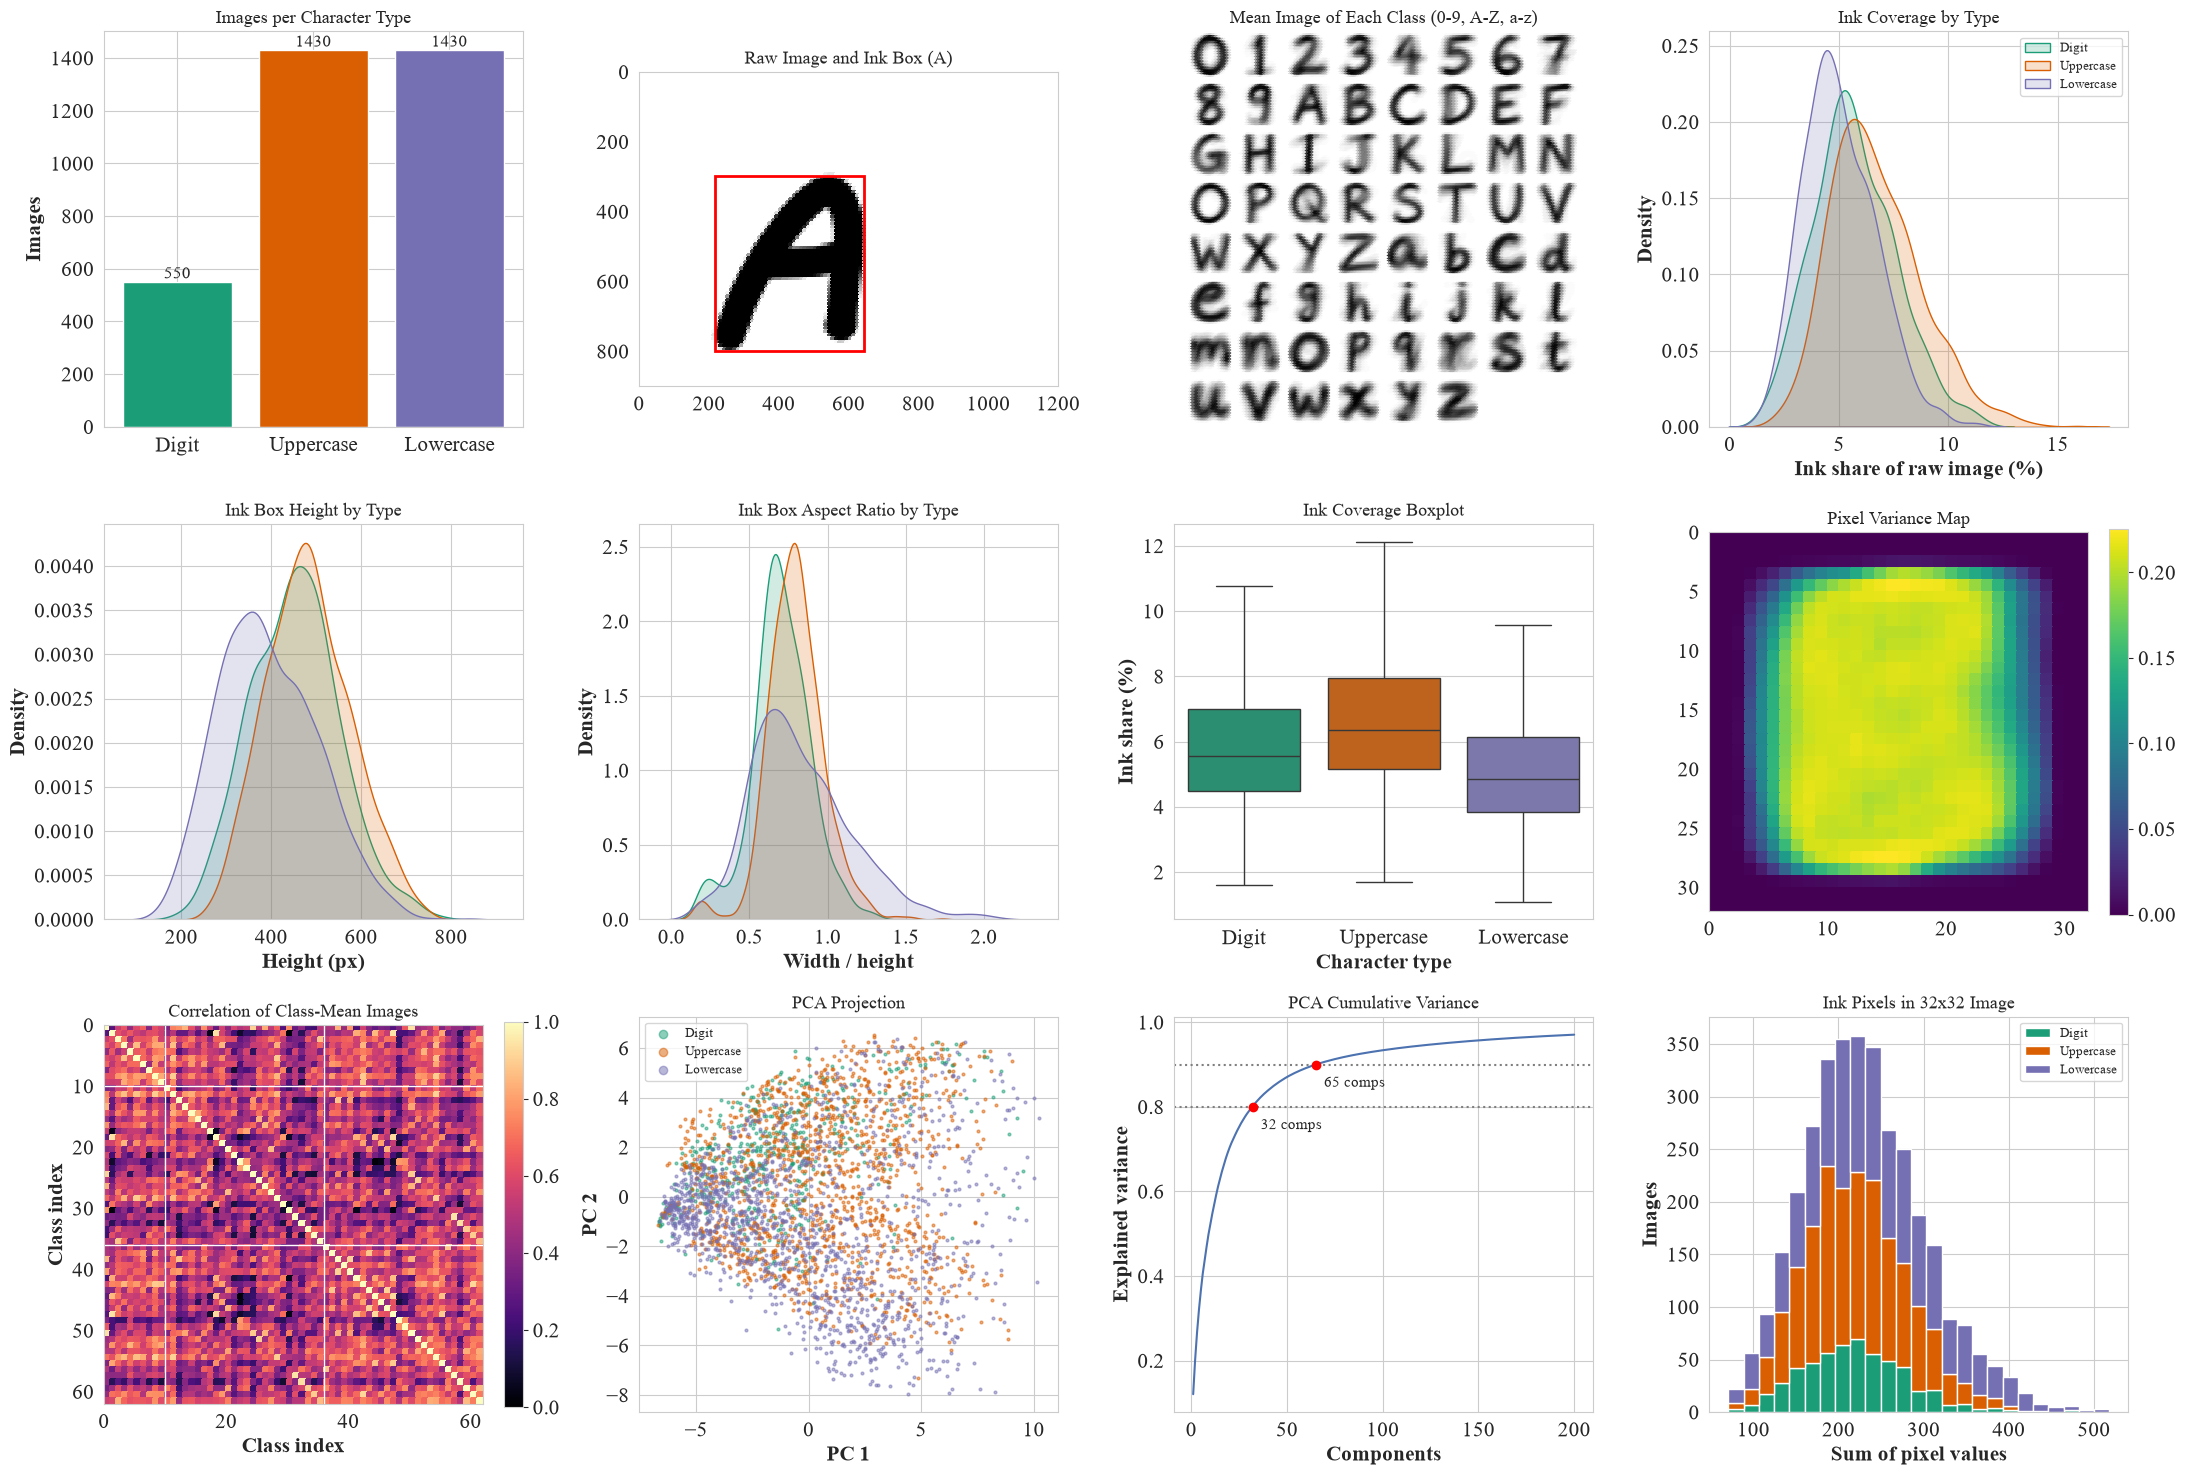

PCA (200 comps) explained variance: 0.9707 | comps for 80%: 32 | for 90%: 65 | for 95%: 132
Median ink box height / width (px): 443 / 331
Digit: 550 images, median ink coverage 5.57%, median box height 452px
Uppercase: 1430 images, median ink coverage 6.37%, median box height 478px
Lowercase: 1430 images, median ink coverage 4.84%, median box height 382px


In [7]:
eda_fig, pca_eda = build_eda_summary_figure()
eda_fig.savefig("figures/00_eda_summary.eps", format="eps", dpi=600)
eda_fig.savefig("figures/00_eda_summary.png", dpi=150)
plt.show()
plt.close(eda_fig)

cum = np.cumsum(pca_eda.explained_variance_ratio_)
def comps_for(level):
    return int(np.argmax(cum >= level)) + 1 if cum[-1] >= level else None

log("PCA (200 comps) explained variance:", round(float(cum[-1]), 4), "| comps for 80%:", comps_for(0.8), "| for 90%:", comps_for(0.9),
    "| for 95%:", comps_for(0.95))
log("Median ink box height / width (px):", int(np.median(box_h)), "/", int(np.median(box_w)))
for g in GROUP_ORDER:
    m = groups == g
    log(f"{g}: {int(m.sum())} images, median ink coverage {np.median(ink_frac[m]) * 100:.2f}%, median box height {int(np.median(box_h[m]))}px")

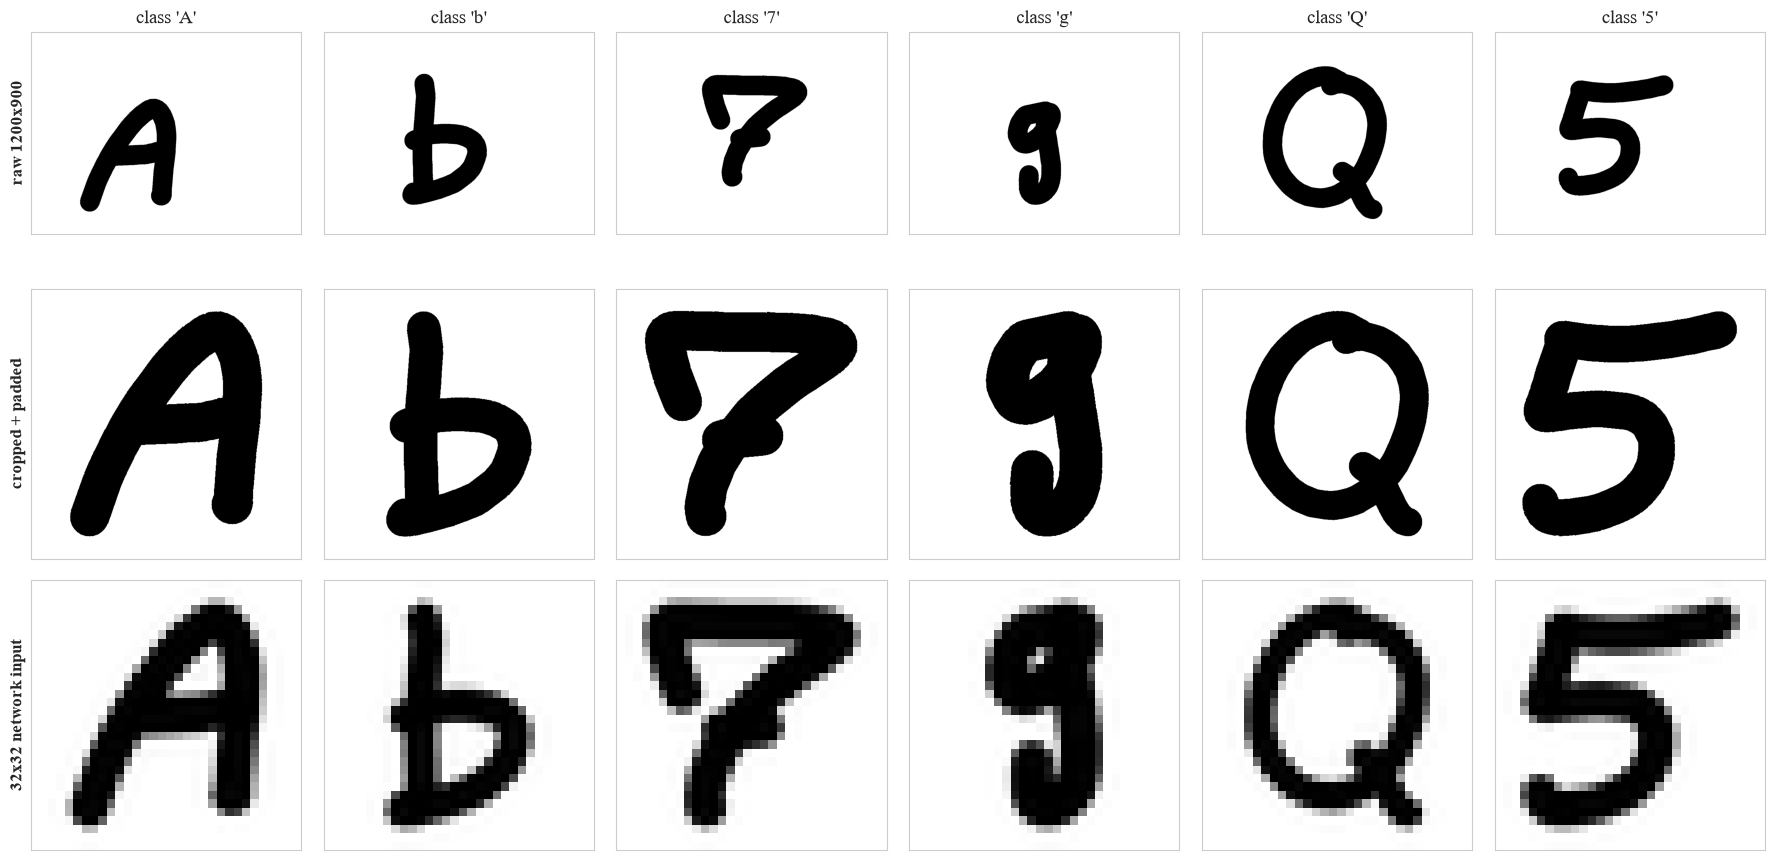

In [8]:
demo_labels = ["A", "b", "7", "g", "Q", "5"]
fig, axes = plt.subplots(3, len(demo_labels), figsize=(3 * len(demo_labels), 9))
for j, lab in enumerate(demo_labels):
    path = meta.loc[meta["label"] == lab, "image"].iloc[0]
    gray = np.array(Image.open(path).convert("L"))
    canvas, _, _, _ = square_crop(gray)
    small = preprocess_image(path)[0]
    for i, (im, name) in enumerate([(gray, "raw 1200x900"), (canvas, "cropped + padded"), (small, "32x32 network input")]):
        axes[i, j].imshow(im, cmap="gray" if i == 0 else "gray_r")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        axes[i, j].grid(False)
        if j == 0:
            axes[i, j].set_ylabel(name, fontsize=12)
    axes[0, j].set_title(f"class '{lab}'", fontsize=14)
plt.tight_layout()
plt.savefig("figures/01_preprocessing_steps.png", dpi=150)
plt.show()
plt.close()

## Model A: perceptron from scratch

In [9]:
class Perceptron:
    def __init__(self, n_features, n_classes, lr=1.0, seed=RNG):
        self.W = np.zeros((n_features + 1, n_classes))
        self.lr = lr
        self.n_classes = n_classes
        self.rng = np.random.default_rng(seed)

    def scores(self, X):
        return X @ self.W[:-1] + self.W[-1]

    def predict(self, X):
        return self.scores(X).argmax(axis=1)

    def fit(self, X, y, epochs, X_val=None, y_val=None):
        Y = np.eye(self.n_classes)[y]
        history = []
        for epoch in range(epochs):
            mistakes = 0
            for i in self.rng.permutation(len(X)):
                out = (X[i] @ self.W[:-1] + self.W[-1] > 0).astype(float)
                err = Y[i] - out
                wrong = np.nonzero(err)[0]
                if len(wrong):
                    self.W[:-1, wrong] += self.lr * np.outer(X[i], err[wrong])
                    self.W[-1, wrong] += self.lr * err[wrong]
                    mistakes += len(wrong)
            row = dict(epoch=epoch + 1, mistakes=mistakes, train_err=1 - accuracy_score(y, self.predict(X)))
            if X_val is not None:
                row["val_err"] = 1 - accuracy_score(y_val, self.predict(X_val))
            history.append(row)
        return pd.DataFrame(history)

In [10]:
pla_inputs = {"pixels in [0, 1]": (X_train, X_val, X_test), "standardized pixels": (X_train_std, X_val_std, X_test_std)}
pla_runs, pla_rows = {}, []
for scaling, (Xa, Xb, _) in pla_inputs.items():
    for lr in [0.01, 0.1, 1.0]:
        t0 = time.perf_counter()
        model = Perceptron(Xa.shape[1], N_CLASSES, lr=lr, seed=RNG)
        hist = model.fit(Xa, y_train, PLA_EPOCHS, Xb, y_val)
        pla_runs[(scaling, lr)] = hist
        pla_rows.append(dict(scaling=scaling, lr=lr, final_train_acc=1 - hist["train_err"].iloc[-1],
                             final_val_acc=1 - hist["val_err"].iloc[-1], best_val_acc=1 - hist["val_err"].min(),
                             best_epoch=int(hist["val_err"].idxmin()) + 1, zero_mistake_epochs=int((hist["mistakes"] == 0).sum()),
                             seconds=time.perf_counter() - t0))
pla_df = pd.DataFrame(pla_rows)
pla_df.to_csv("pla_tuning.csv", index=False)
log("PLA tuning (zero initial weights, one shuffle seed):")
log(pla_df.round(4).to_string(index=False))

same = pla_df.groupby("scaling")["best_val_acc"].nunique()
log("\nDistinct best-val-accuracy values across the three learning rates, per scaling:", same.to_dict())

PLA tuning (zero initial weights, one shuffle seed):
            scaling   lr  final_train_acc  final_val_acc  best_val_acc  best_epoch  zero_mistake_epochs  seconds
   pixels in [0, 1] 0.01           0.9975         0.6855        0.6973          77                    0   4.0596
   pixels in [0, 1] 0.10           0.9975         0.6855        0.6973          77                    0   3.9790
   pixels in [0, 1] 1.00           0.9975         0.6855        0.6973          77                    0   4.0164
standardized pixels 0.01           0.9916         0.5059        0.5137          47                    0   4.5924
standardized pixels 0.10           0.9916         0.5059        0.5137          47                    0   4.2489
standardized pixels 1.00           0.9916         0.5059        0.5137          47                    0   4.3031

Distinct best-val-accuracy values across the three learning rates, per scaling: {'pixels in [0, 1]': 1, 'standardized pixels': 1}



Chosen PLA setting: pixels in [0, 1] | epochs (best validation epoch): 77 | lr: 1.0 (any value gives the same predictions)


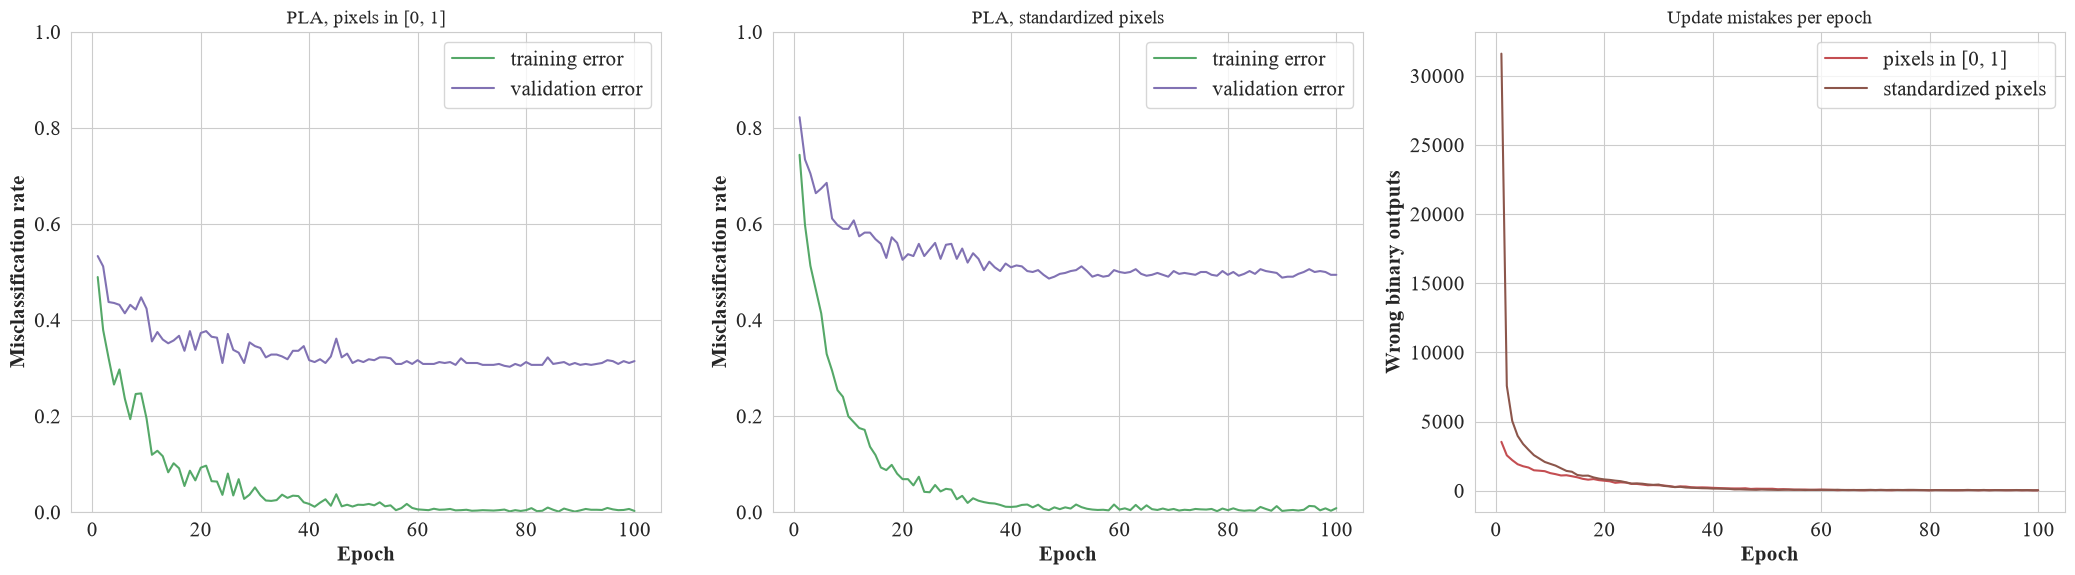

In [11]:
pla_best = pla_df.sort_values(["best_val_acc", "final_val_acc"], ascending=False).iloc[0]
PLA_SCALING, PLA_EPOCHS_BEST = pla_best["scaling"], int(pla_best["best_epoch"])
log("\nChosen PLA setting:", PLA_SCALING, "| epochs (best validation epoch):", PLA_EPOCHS_BEST, "| lr: 1.0 (any value gives the same predictions)")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, scaling in zip(axes[:2], pla_inputs):
    h = pla_runs[(scaling, 1.0)]
    ax.plot(h["epoch"], h["train_err"], color=SPLIT_COLORS["train"], label="training error")
    ax.plot(h["epoch"], h["val_err"], color=SPLIT_COLORS["val"], label="validation error")
    ax.set_title(f"PLA, {scaling}", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Misclassification rate")
    ax.set_ylim(0, 1)
    ax.legend()
for scaling, color in zip(pla_inputs, ["#c44e52", "#8c564b"]):
    axes[2].plot(pla_runs[(scaling, 1.0)]["epoch"], pla_runs[(scaling, 1.0)]["mistakes"], color=color, label=scaling)
axes[2].set_title("Update mistakes per epoch", fontsize=14)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Wrong binary outputs")
axes[2].legend()
plt.tight_layout()
plt.savefig("figures/02_pla_training_curves.png", dpi=150)
plt.show()
plt.close()

## Model B: MLP training function

In [12]:
Xtr_t = torch.tensor(X_train, device=device)
Xva_t = torch.tensor(X_val, device=device)
Xte_t = torch.tensor(X_test, device=device)
ytr_t = torch.tensor(y_train, device=device)
yva_t = torch.tensor(y_val, device=device)
yte_t = torch.tensor(y_test, device=device)

def augment(xb):
    B = xb.shape[0]
    img = xb.view(B, 1, 32, 32)
    ang = (torch.rand(B, device=device) * 2 - 1) * (10 * np.pi / 180)
    sc = 1 + (torch.rand(B, device=device) * 2 - 1) * 0.1
    tx = (torch.rand(B, device=device) * 2 - 1) * 0.125
    ty = (torch.rand(B, device=device) * 2 - 1) * 0.125
    cos, sin = torch.cos(ang) / sc, torch.sin(ang) / sc
    theta = torch.stack([torch.stack([cos, -sin, tx], dim=1), torch.stack([sin, cos, ty], dim=1)], dim=1)
    grid = F.affine_grid(theta, img.shape, align_corners=False)
    return F.grid_sample(img, grid, padding_mode="zeros", align_corners=False).view(B, -1)

def run_mlp(cfg, epochs=EPOCHS, seed=RNG, patience=None):
    torch.manual_seed(seed)
    model = make_mlp(cfg["hidden"], cfg["activation"], cfg.get("dropout", 0.0))
    opt = make_optimizer(model, cfg)
    loss_fn = LOSSES[cfg["cost"]]
    n = Xtr_t.shape[0]
    bs = n if cfg["optimizer"] == "GD" else cfg["batch"]
    rec, best_loss, best_state, best_epoch, wait = [], float("inf"), None, 0, 0
    t0 = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n, device=device)
        for i in range(0, n, bs):
            b = perm[i:i + bs]
            xb = Xtr_t[b]
            if cfg.get("augment"):
                xb = augment(xb)
            opt.zero_grad(set_to_none=True)
            loss_fn(model(xb), ytr_t[b]).backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            lt, lv = model(Xtr_t), model(Xva_t)
            rec.append(torch.stack([loss_fn(lt, ytr_t), (lt.argmax(1) != ytr_t).float().mean(),
                                    loss_fn(lv, yva_t), (lv.argmax(1) != yva_t).float().mean()]))
        if patience:
            v = rec[-1][2].item()
            if v < best_loss - 1e-4:
                best_loss, best_epoch, wait = v, epoch, 0
                best_state = copy.deepcopy(model.state_dict())
            else:
                wait += 1
                if wait >= patience:
                    break
    if patience and best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        train_acc = (model(Xtr_t).argmax(1) == ytr_t).float().mean().item()
        val_acc = (model(Xva_t).argmax(1) == yva_t).float().mean().item()
    hist = torch.stack(rec).cpu().numpy()
    return dict(hist=hist, model=model, train_acc=train_acc, val_acc=val_acc, epochs_run=len(hist),
                stopped_at=(best_epoch + 1 if patience else len(hist)), seconds=time.perf_counter() - t0)

def predict_logits(model, X_t):
    model.eval()
    with torch.no_grad():
        return model(X_t).cpu().numpy()

def epochs_to(hist, col, threshold, below=False):
    series = hist[:, col]
    hit = np.where(series <= threshold)[0] if below else np.where(series >= threshold)[0]
    return int(hit[0]) + 1 if len(hit) else np.nan

smoke = run_mlp(dict(hidden=[256], activation="relu", cost="CE", optimizer="Adam", lr=0.001, batch=128), epochs=5)
log("Smoke test, 5 epochs:", "train acc", round(smoke["train_acc"], 3), "| val acc", round(smoke["val_acc"], 3), "| params", count_params(smoke["model"]))

Smoke test, 5 epochs: train acc 0.753 | val acc 0.662 | params 278334


## Tuning grid: activation x cost x optimizer x learning rate x batch size

In [13]:
ACTIVATIONS = ["relu", "tanh", "sigmoid"]
COSTS = ["CE", "MSE"]
OPTIMIZERS = ["GD", "SGD", "SGD+momentum", "Adam"]

grid_rows, grid_curves = [], {}
t_grid = time.perf_counter()
for cost in COSTS:
    for act in ACTIVATIONS:
        for opt_name in OPTIMIZERS:
            for lr in GRID_LRS:
                for bs in ([N_TRAIN] if opt_name == "GD" else GRID_BATCHES):
                    cfg = dict(hidden=[256], activation=act, cost=cost, optimizer=opt_name, lr=lr, batch=bs)
                    res = run_mlp(cfg)
                    h = res["hist"]
                    grid_rows.append(dict(activation=act, cost=cost, optimizer=opt_name, lr=lr, batch=bs,
                                          train_acc=res["train_acc"], val_acc=res["val_acc"],
                                          best_val_acc=1 - h[:, 3].min(), best_epoch=int(h[:, 3].argmin()) + 1,
                                          final_train_loss=h[-1, 0], seconds=res["seconds"]))
                    grid_curves[(act, cost, opt_name, lr, bs)] = h
grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv("mlp_tuning_grid.csv", index=False)
log("Grid runs:", len(grid_df), "| total time:", round(time.perf_counter() - t_grid, 1), "s")
log("Validation accuracy over the grid: min", round(grid_df["val_acc"].min(), 4), "| median", round(grid_df["val_acc"].median(), 4),
    "| max", round(grid_df["val_acc"].max(), 4))
log("Runs at or below 5% validation accuracy:", int((grid_df["val_acc"] <= 0.05).sum()), "of", len(grid_df))
log("\nTop 10 grid runs by validation accuracy (one seed):")
log(grid_df.sort_values("val_acc", ascending=False).head(10).round(4).to_string(index=False))

Grid runs: 180 | total time: 426.3 s
Validation accuracy over the grid: min 0.0156 | median 0.5898 | max 0.7773
Runs at or below 5% validation accuracy: 43 of 180

Top 10 grid runs by validation accuracy (one seed):
activation cost    optimizer    lr  batch  train_acc  val_acc  best_val_acc  best_epoch  final_train_loss  seconds
   sigmoid   CE         Adam 0.010    512     0.9996   0.7773        0.7871          20            0.0073   0.4290
   sigmoid   CE         Adam 0.001    512     0.9489   0.7773        0.7773          94            0.2818   0.4877
      tanh   CE         Adam 0.001    512     0.9941   0.7734        0.7812          85            0.0542   0.4557
   sigmoid   CE         Adam 0.001    128     0.9937   0.7734        0.7832          97            0.0662   1.5098
      tanh   CE          SGD 0.100     32     0.9971   0.7715        0.7734          33            0.0314   4.5882
   sigmoid   CE         Adam 0.001     32     0.9971   0.7715        0.7891          46       

## Which hyperparameters matter most

In [14]:
factors = ["activation", "cost", "optimizer", "lr", "batch"]

def marginal(df, factor):
    sub = df[df["optimizer"] != "GD"] if factor == "batch" else df
    g = sub.groupby(factor)["val_acc"].agg(["mean", "max", "min", "count"]).reset_index()
    g = g.rename(columns={factor: "value"})
    g.insert(0, "factor", factor)
    return g

marg = pd.concat([marginal(grid_df, f) for f in factors], ignore_index=True)
marg.to_csv("mlp_marginal_effects.csv", index=False)
log("Mean / best / worst validation accuracy for each value of each hyperparameter (whole grid):")
log(marg.round(4).to_string(index=False))

spread = pd.DataFrame([dict(factor=f,
                            spread_of_means=marg[marg["factor"] == f]["mean"].max() - marg[marg["factor"] == f]["mean"].min(),
                            spread_of_best=marg[marg["factor"] == f]["max"].max() - marg[marg["factor"] == f]["max"].min())
                       for f in factors]).sort_values("spread_of_means", ascending=False)
spread.to_csv("mlp_factor_spread.csv", index=False)
log("\nSpread across values (max minus min), per hyperparameter:")
log(spread.round(4).to_string(index=False))

Mean / best / worst validation accuracy for each value of each hyperparameter (whole grid):
    factor        value   mean    max    min  count
activation         relu 0.4529 0.7637 0.0156     60
activation      sigmoid 0.3957 0.7773 0.0156     60
activation         tanh 0.4723 0.7734 0.0156     60
      cost           CE 0.5709 0.7773 0.0156     90
      cost          MSE 0.3097 0.7637 0.0156     90
 optimizer         Adam 0.5442 0.7773 0.0156     54
 optimizer           GD 0.1229 0.6309 0.0156     18
 optimizer          SGD 0.3479 0.7715 0.0176     54
 optimizer SGD+momentum 0.5345 0.7695 0.0176     54
        lr        0.001 0.3680 0.7773 0.0156     60
        lr         0.01 0.4820 0.7773 0.0156     60
        lr          0.1 0.4709 0.7715 0.0156     60
     batch           32 0.5262 0.7715 0.0156     54
     batch          128 0.4874 0.7734 0.0156     54
     batch          512 0.4130 0.7773 0.0156     54

Spread across values (max minus min), per hyperparameter:
    factor  sprea

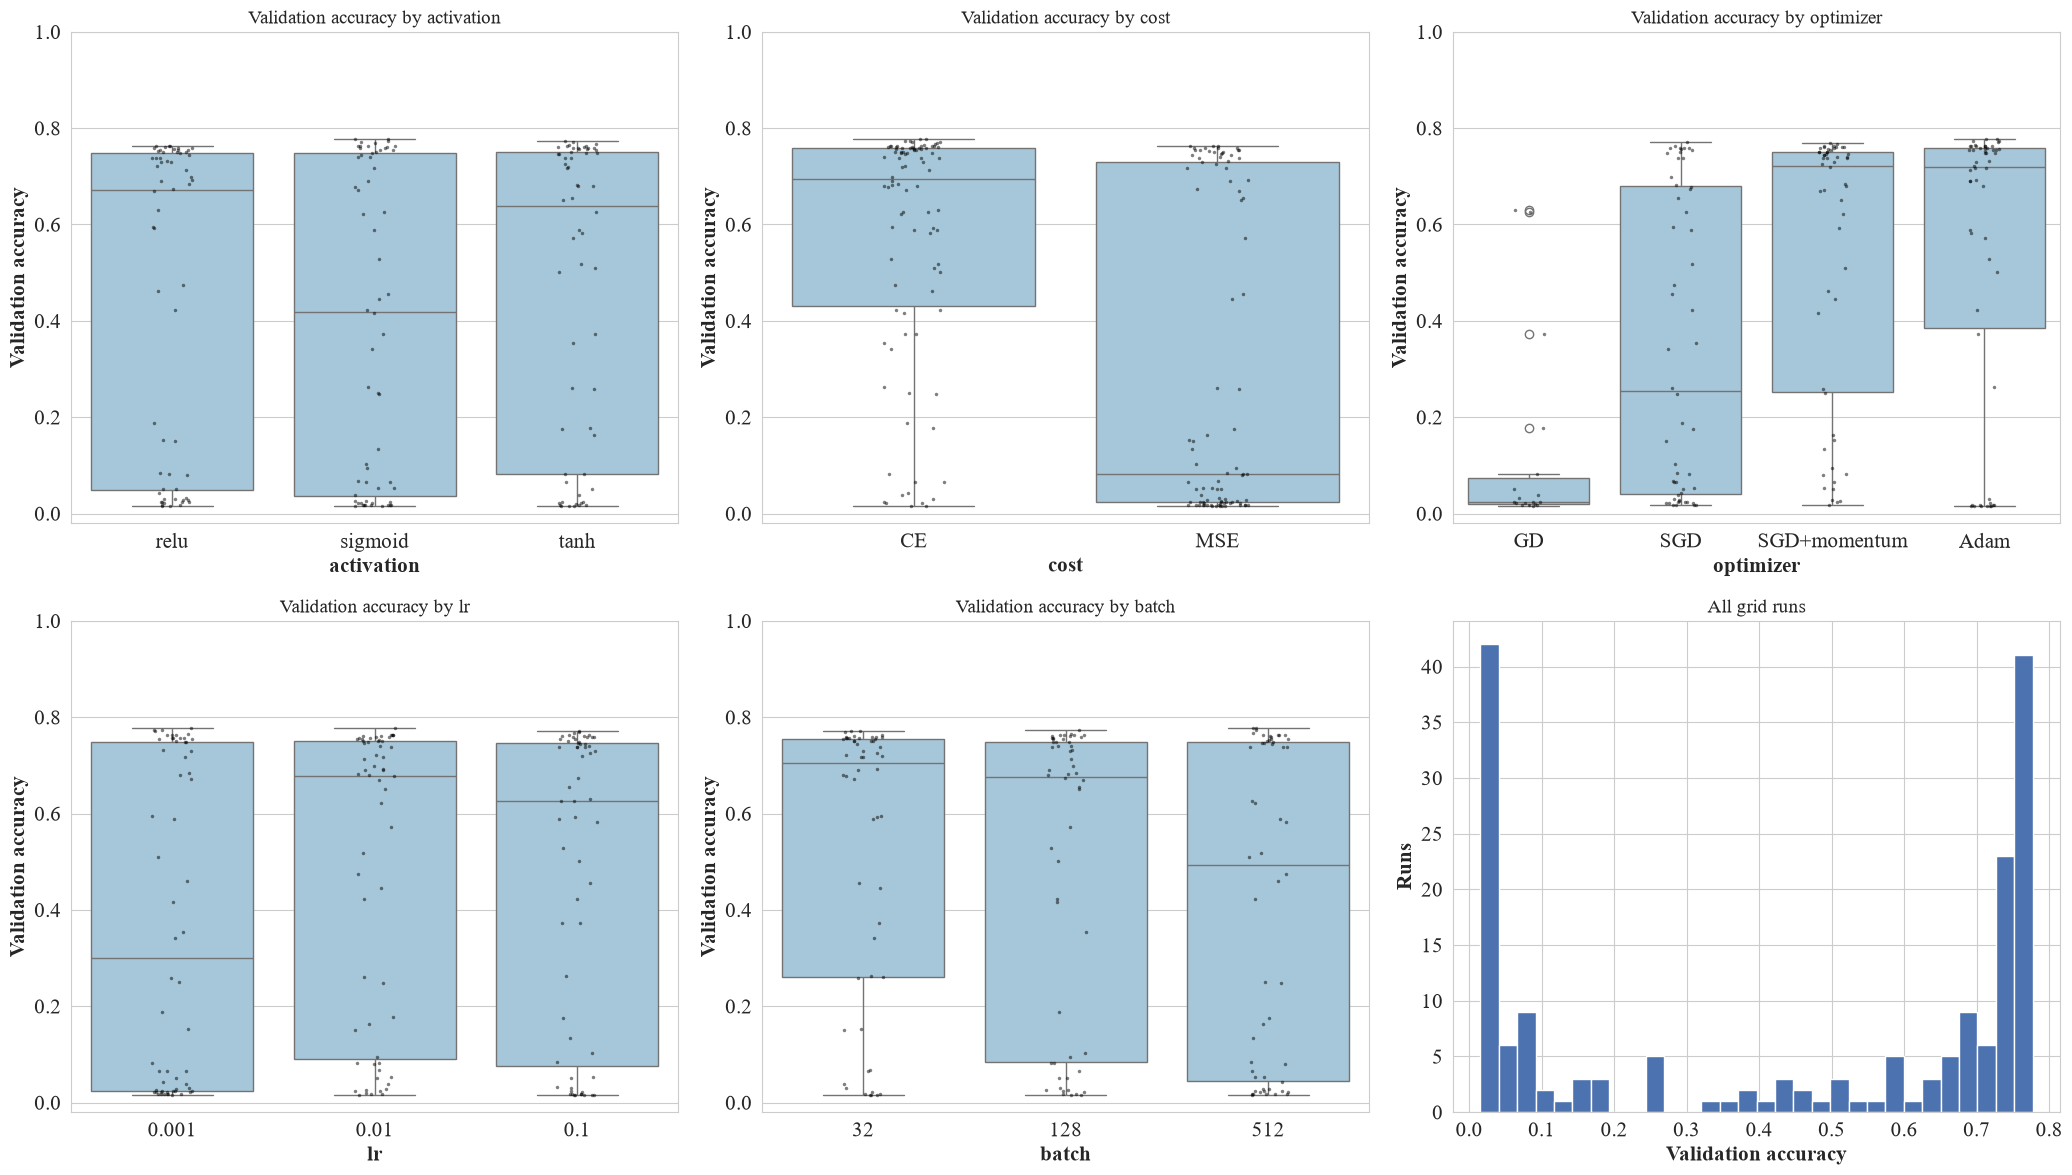

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
for ax, f in zip(axes.ravel()[:5], factors):
    sub = grid_df[grid_df["optimizer"] != "GD"] if f == "batch" else grid_df
    order = OPTIMIZERS if f == "optimizer" else sorted(sub[f].unique())
    sns.boxplot(data=sub, x=f, y="val_acc", order=order, color="#9ecae1", ax=ax, showfliers=True)
    sns.stripplot(data=sub, x=f, y="val_acc", order=order, color="black", size=2.5, alpha=0.5, ax=ax)
    ax.set_title(f"Validation accuracy by {f}", fontsize=14)
    ax.set_xlabel(f)
    ax.set_ylabel("Validation accuracy")
    ax.set_ylim(-0.02, 1)
axes[1, 2].hist(grid_df["val_acc"], bins=30, color="#4c72b0")
axes[1, 2].set_title("All grid runs", fontsize=14)
axes[1, 2].set_xlabel("Validation accuracy")
axes[1, 2].set_ylabel("Runs")
plt.tight_layout()
plt.savefig("figures/03_tuning_grid_overview.png", dpi=150)
plt.show()
plt.close()

## Re-running the best grid configs with more seeds

In [16]:
def row_to_cfg(r):
    return dict(hidden=[256], activation=r["activation"], cost=r["cost"], optimizer=r["optimizer"], lr=float(r["lr"]), batch=int(r["batch"]))

SEEDS = [RNG] + EXTRA_SEEDS
top = grid_df.sort_values("val_acc", ascending=False).head(TOP_K)
top_rows = []
for _, r in top.iterrows():
    cfg = row_to_cfg(r)
    accs = [r["val_acc"]] + [run_mlp(cfg, seed=s)["val_acc"] for s in EXTRA_SEEDS]
    top_rows.append(dict(activation=cfg["activation"], cost=cfg["cost"], optimizer=cfg["optimizer"], lr=cfg["lr"], batch=cfg["batch"],
                         seed42_val_acc=r["val_acc"], mean_val_acc=np.mean(accs), std_val_acc=np.std(accs)))
top_df = pd.DataFrame(top_rows).sort_values("mean_val_acc", ascending=False).reset_index(drop=True)
top_df.to_csv("mlp_top_configs.csv", index=False)
log(f"Top {TOP_K} grid configs re-run with {len(SEEDS)} seeds:")
log(top_df.round(4).to_string(index=False))

best_cfg = row_to_cfg(top_df.iloc[0])
log("\nBest grid config:", best_cfg)

Top 6 grid configs re-run with 4 seeds:
activation cost optimizer    lr  batch  seed42_val_acc  mean_val_acc  std_val_acc
   sigmoid   CE      Adam 0.010    512          0.7773        0.7783       0.0070
   sigmoid   CE      Adam 0.001    128          0.7734        0.7754       0.0057
   sigmoid   CE      Adam 0.001     32          0.7715        0.7749       0.0059
      tanh   CE      Adam 0.001    512          0.7734        0.7729       0.0021
   sigmoid   CE      Adam 0.001    512          0.7773        0.7671       0.0070
      tanh   CE       SGD 0.100     32          0.7715        0.7656       0.0050

Best grid config: {'hidden': [256], 'activation': 'sigmoid', 'cost': 'CE', 'optimizer': 'Adam', 'lr': 0.01, 'batch': 512}


In [17]:
def neighbour(best, factor, value):
    q = dict(best)
    q[factor] = value
    if q["optimizer"] == "GD":
        q["batch"] = N_TRAIN
    elif best["optimizer"] == "GD":
        q["batch"] = 128
    m = np.ones(len(grid_df), dtype=bool)
    for k in ["activation", "cost", "optimizer", "lr", "batch"]:
        m &= (grid_df[k] == q[k]).to_numpy()
    return float(grid_df.loc[m, "val_acc"].iloc[0]) if m.any() else np.nan

base_acc = neighbour(best_cfg, "activation", best_cfg["activation"])
around = []
for f, values in [("activation", ACTIVATIONS), ("cost", COSTS), ("optimizer", OPTIMIZERS), ("lr", GRID_LRS), ("batch", GRID_BATCHES)]:
    for v in values:
        acc = neighbour(best_cfg, f, v)
        around.append(dict(factor=f, value=v, val_acc=acc, change_vs_best=acc - base_acc, is_best=(best_cfg[f] == v)))
around_df = pd.DataFrame(around)
around_df.to_csv("mlp_one_factor_from_best.csv", index=False)
log("Changing one hyperparameter at a time away from the best grid config (seed 42 grid runs):")
log(around_df.round(4).to_string(index=False))

Changing one hyperparameter at a time away from the best grid config (seed 42 grid runs):
    factor        value  val_acc  change_vs_best  is_best
activation         relu   0.7539         -0.0234    False
activation         tanh   0.7637         -0.0137    False
activation      sigmoid   0.7773          0.0000     True
      cost           CE   0.7773          0.0000     True
      cost          MSE   0.7637         -0.0137    False
 optimizer           GD   0.0391         -0.7383    False
 optimizer          SGD   0.2480         -0.5293    False
 optimizer SGD+momentum   0.6211         -0.1562    False
 optimizer         Adam   0.7773          0.0000     True
        lr        0.001   0.7773          0.0000    False
        lr         0.01   0.7773          0.0000     True
        lr          0.1   0.5879         -0.1895    False
     batch           32   0.6895         -0.0879    False
     batch          128   0.7637         -0.0137    False
     batch          512   0.7773        

## SGD vs Adam convergence

Across every (lr, batch) setting of each optimizer (same activation and cost), how many reached the targets within 100 epochs:
   optimizer  configs  best_val_acc  median_val_acc  reach_train90  fastest_train90  reach_val50  fastest_val50
          GD        3        0.3730          0.0391              0              NaN            0            NaN
         SGD        9        0.7598          0.4219              1             64.0            4            7.0
SGD+momentum        9        0.7695          0.7402              4             11.0            7            2.0
        Adam        9        0.7773          0.7637              6              7.0            8            2.0
Each optimizer at its own best (lr, batch), activation and cost fixed to the grid winner's:
   optimizer   lr  batch  final_val_acc  epochs_to_val_acc_40  epochs_to_val_acc_50  epochs_to_train_acc_90  final_train_loss
          GD 0.10   2386         0.3730                   NaN                   NaN            

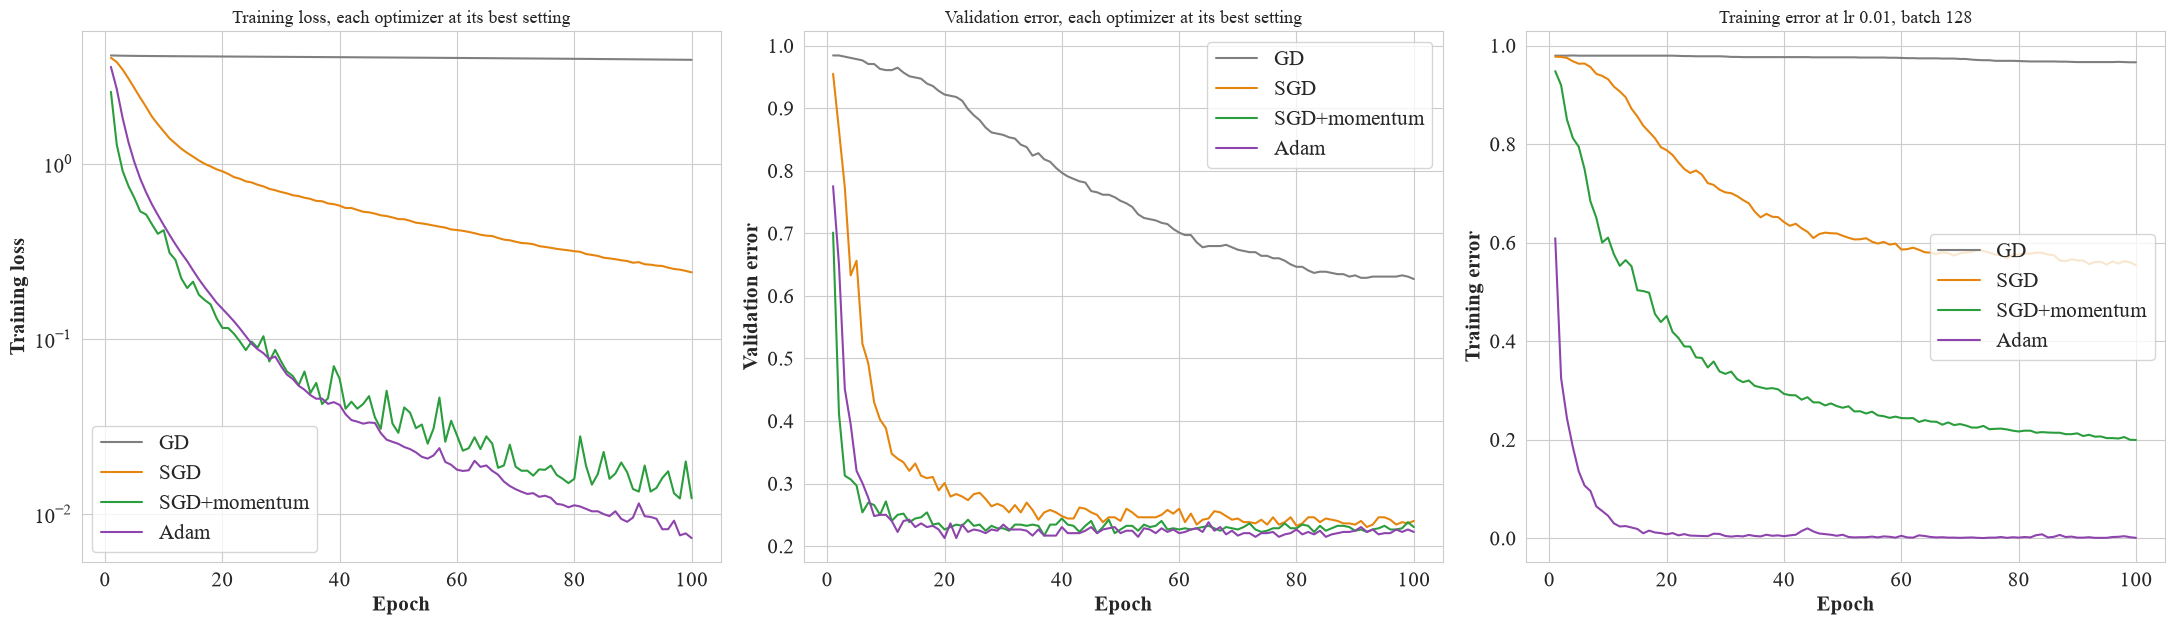

In [18]:
OPT_COLORS = {"GD": "#7f7f7f", "SGD": "#e6850e", "SGD+momentum": "#2a9d3c", "Adam": "#8e44ad"}

same_ac = grid_df[(grid_df["activation"] == best_cfg["activation"]) & (grid_df["cost"] == best_cfg["cost"])].copy()
same_ac["train90"] = [epochs_to(grid_curves[(r.activation, r.cost, r.optimizer, r.lr, int(r.batch))], 1, 0.10, below=True) for r in same_ac.itertuples()]
same_ac["val50"] = [epochs_to(grid_curves[(r.activation, r.cost, r.optimizer, r.lr, int(r.batch))], 3, 0.5, below=True) for r in same_ac.itertuples()]
speed_df = same_ac.groupby("optimizer").agg(configs=("val_acc", "size"), best_val_acc=("val_acc", "max"), median_val_acc=("val_acc", "median"),
                                             reach_train90=("train90", lambda s: int(s.notna().sum())), fastest_train90=("train90", "min"),
                                             reach_val50=("val50", lambda s: int(s.notna().sum())), fastest_val50=("val50", "min")).reindex(OPTIMIZERS).reset_index()
speed_df.to_csv("optimizer_speed_summary.csv", index=False)
log("Across every (lr, batch) setting of each optimizer (same activation and cost), how many reached the targets within", EPOCHS, "epochs:")
log(speed_df.round(4).to_string(index=False))

conv_rows, conv_curves = [], {}
for o in OPTIMIZERS:
    sub = same_ac[same_ac["optimizer"] == o].sort_values(["val_acc", "train90"], ascending=[False, True])
    r = sub.iloc[0]
    h = grid_curves[(r["activation"], r["cost"], r["optimizer"], r["lr"], int(r["batch"]))]
    conv_curves[o] = h
    conv_rows.append(dict(optimizer=o, lr=r["lr"], batch=int(r["batch"]), final_val_acc=1 - h[-1, 3],
                          epochs_to_val_acc_40=epochs_to(h, 3, 0.6, below=True), epochs_to_val_acc_50=epochs_to(h, 3, 0.5, below=True),
                          epochs_to_train_acc_90=epochs_to(h, 1, 0.10, below=True), final_train_loss=h[-1, 0]))
conv_df = pd.DataFrame(conv_rows)
conv_df.to_csv("optimizer_convergence.csv", index=False)
log("Each optimizer at its own best (lr, batch), activation and cost fixed to the grid winner's:")
log(conv_df.round(4).to_string(index=False))

fixed = grid_df[(grid_df["activation"] == best_cfg["activation"]) & (grid_df["cost"] == best_cfg["cost"]) & (grid_df["lr"] == 0.01)
                & ((grid_df["batch"] == 128) | (grid_df["optimizer"] == "GD"))]
log("\nSame learning rate (0.01) and batch size (128), optimizers compared directly:")
log(fixed[["optimizer", "lr", "batch", "train_acc", "val_acc", "final_train_loss"]].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
for o, h in conv_curves.items():
    ep = np.arange(1, len(h) + 1)
    axes[0].plot(ep, h[:, 0], color=OPT_COLORS[o], label=o)
    axes[1].plot(ep, h[:, 3], color=OPT_COLORS[o], label=o)
for _, r in fixed.iterrows():
    h = grid_curves[(r["activation"], r["cost"], r["optimizer"], r["lr"], int(r["batch"]))]
    axes[2].plot(np.arange(1, len(h) + 1), h[:, 1], color=OPT_COLORS[r["optimizer"]], label=r["optimizer"])
axes[0].set_yscale("log")
axes[0].set_title("Training loss, each optimizer at its best setting", fontsize=13)
axes[0].set_ylabel("Training loss")
axes[1].set_title("Validation error, each optimizer at its best setting", fontsize=13)
axes[1].set_ylabel("Validation error")
axes[2].set_title("Training error at lr 0.01, batch 128", fontsize=13)
axes[2].set_ylabel("Training error")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
axes[2].legend(loc="center right")
plt.tight_layout()
plt.savefig("figures/04_optimizer_convergence.png", dpi=150)
plt.show()
plt.close()

## How many hidden layers and how wide

In [19]:
def multi_seed(cfg, seeds=SEEDS, **kw):
    runs = [run_mlp(cfg, seed=s, **kw) for s in seeds]
    return dict(train_acc=np.mean([r["train_acc"] for r in runs]), train_std=np.std([r["train_acc"] for r in runs]),
                val_acc=np.mean([r["val_acc"] for r in runs]), val_std=np.std([r["val_acc"] for r in runs]),
                params=count_params(runs[0]["model"]), epochs=np.mean([r["stopped_at"] for r in runs]),
                seconds=np.mean([r["seconds"] for r in runs]), runs=runs)

depth_rows = []
for d in range(0, 6):
    cfg = {**best_cfg, "hidden": [256] * d}
    r = multi_seed(cfg)
    depth_rows.append(dict(hidden_layers=d, width=256 if d else 0, params=r["params"], train_acc=r["train_acc"], train_std=r["train_std"],
                           val_acc=r["val_acc"], val_std=r["val_std"], gap=r["train_acc"] - r["val_acc"], seconds=r["seconds"]))
depth_df = pd.DataFrame(depth_rows)
depth_df.to_csv("depth_results.csv", index=False)
log(f"Number of hidden layers (width 256, best grid config, mean of {len(SEEDS)} seeds); 0 layers is a plain softmax classifier:")
log(depth_df.round(4).to_string(index=False))
mlp_depths = depth_df[depth_df["hidden_layers"] >= 1]
best_depth = int(mlp_depths.loc[mlp_depths["val_acc"].idxmax(), "hidden_layers"])
log("Best depth (1 or more hidden layers) by mean validation accuracy:", best_depth)

dact_rows = []
for act in ACTIVATIONS:
    for d in range(1, 6):
        cfg = dict(hidden=[256] * d, activation=act, cost="CE", optimizer="Adam", lr=0.001, batch=128)
        r = multi_seed(cfg)
        dact_rows.append(dict(activation=act, hidden_layers=d, params=r["params"], train_acc=r["train_acc"], val_acc=r["val_acc"],
                              val_std=r["val_std"], gap=r["train_acc"] - r["val_acc"]))
dact_df = pd.DataFrame(dact_rows)
dact_df.to_csv("depth_by_activation.csv", index=False)
log(f"\nDepth again with Adam (lr 0.001, batch 128, cross-entropy) for each activation (mean of {len(SEEDS)} seeds):")
log(dact_df.round(4).to_string(index=False))

Number of hidden layers (width 256, best grid config, mean of 4 seeds); 0 layers is a plain softmax classifier:
 hidden_layers  width  params  train_acc  train_std  val_acc  val_std    gap  seconds
             0      0   63550     0.9975     0.0009   0.7280   0.0016 0.2695   0.3249
             1    256  278334     0.9990     0.0005   0.7783   0.0070 0.2206   0.4332
             2    256  344126     0.9993     0.0002   0.7695   0.0073 0.2297   0.5402
             3    256  409918     0.8186     0.2798   0.5874   0.1870 0.2312   0.6539
             4    256  475710     0.0918     0.0848   0.0669   0.0638 0.0249   0.7800
             5    256  541502     0.0244     0.0140   0.0225   0.0118 0.0020   0.8840
Best depth (1 or more hidden layers) by mean validation accuracy: 1



Depth again with Adam (lr 0.001, batch 128, cross-entropy) for each activation (mean of 4 seeds):
activation  hidden_layers  params  train_acc  val_acc  val_std    gap
      relu              1  278334     0.9959   0.7549   0.0105 0.2410
      relu              2  344126     0.9970   0.7695   0.0084 0.2274
      relu              3  409918     0.9951   0.7500   0.0085 0.2451
      relu              4  475710     0.9920   0.7417   0.0176 0.2503
      relu              5  541502     0.9938   0.7300   0.0113 0.2638
      tanh              1  278334     0.9977   0.7676   0.0024 0.2301
      tanh              2  344126     0.9972   0.7676   0.0072 0.2296
      tanh              3  409918     0.9991   0.7734   0.0069 0.2256
      tanh              4  475710     0.9970   0.7627   0.0063 0.2343
      tanh              5  541502     0.9970   0.7490   0.0058 0.2479
   sigmoid              1  278334     0.9925   0.7754   0.0057 0.2171
   sigmoid              2  344126     0.9953   0.7646   0.008


Width of the hidden layer(s) at 1 hidden layer(s):
 hidden_layers  width  params  train_acc  val_acc  val_std    gap  seconds
             1     64   69630     0.9981   0.7407   0.0117 0.2574   0.4424
             1    128  139198     0.9990   0.7598   0.0050 0.2392   0.4466
             1    256  278334     0.9990   0.7783   0.0070 0.2206   0.4349
             1    512  556606     0.9991   0.7793   0.0057 0.2198   0.4509
             1   1024 1113150     0.9993   0.7729   0.0087 0.2263   0.4548
Chosen architecture: [512]


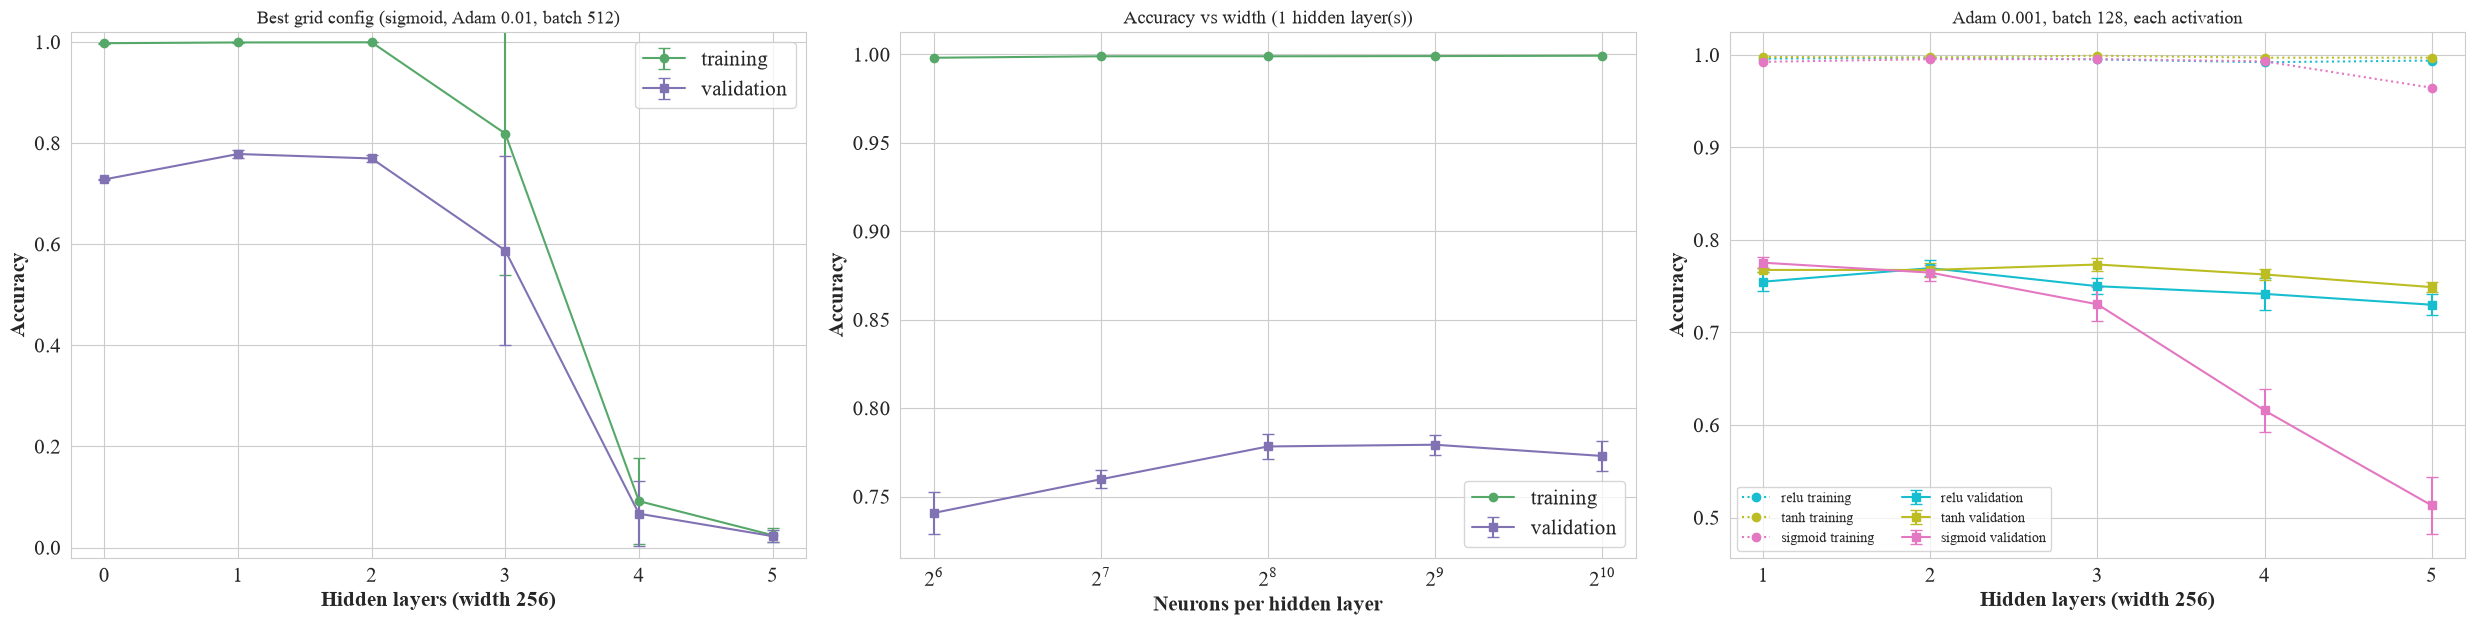

In [20]:
width_rows = []
for w in [64, 128, 256, 512, 1024]:
    cfg = {**best_cfg, "hidden": [w] * best_depth}
    r = multi_seed(cfg)
    width_rows.append(dict(hidden_layers=best_depth, width=w, params=r["params"], train_acc=r["train_acc"], val_acc=r["val_acc"],
                           val_std=r["val_std"], gap=r["train_acc"] - r["val_acc"], seconds=r["seconds"]))
width_df = pd.DataFrame(width_rows)
width_df.to_csv("width_results.csv", index=False)
log(f"\nWidth of the hidden layer(s) at {best_depth} hidden layer(s):")
log(width_df.round(4).to_string(index=False))
best_width = int(width_df.loc[width_df["val_acc"].idxmax(), "width"])
arch_cfg = {**best_cfg, "hidden": [best_width] * best_depth}
log("Chosen architecture:", arch_cfg["hidden"])

ACT_COLORS = {"relu": "#17becf", "tanh": "#bcbd22", "sigmoid": "#e377c2"}
fig, axes = plt.subplots(1, 3, figsize=(25, 6.5))
axes[0].errorbar(depth_df["hidden_layers"], depth_df["train_acc"], yerr=depth_df["train_std"], color=SPLIT_COLORS["train"], marker="o", capsize=4, label="training")
axes[0].errorbar(depth_df["hidden_layers"], depth_df["val_acc"], yerr=depth_df["val_std"], color=SPLIT_COLORS["val"], marker="s", capsize=4, label="validation")
axes[0].set_xlabel("Hidden layers (width 256)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Best grid config (sigmoid, Adam 0.01, batch 512)", fontsize=13)
axes[0].set_ylim(-0.02, 1.02)
axes[0].set_xticks(range(0, 6))
axes[2].set_xticks(range(1, 6))
axes[0].legend()
for act in ACTIVATIONS:
    s = dact_df[dact_df["activation"] == act]
    axes[2].errorbar(s["hidden_layers"], s["val_acc"], yerr=s["val_std"], color=ACT_COLORS[act], marker="s", capsize=4, label=f"{act} validation")
    axes[2].plot(s["hidden_layers"], s["train_acc"], color=ACT_COLORS[act], linestyle=":", marker="o", label=f"{act} training")
axes[2].set_xlabel("Hidden layers (width 256)")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Adam 0.001, batch 128, each activation", fontsize=13)
axes[2].legend(fontsize=10, ncol=2)
axes[1].plot(width_df["width"], width_df["train_acc"], color=SPLIT_COLORS["train"], marker="o", label="training")
axes[1].errorbar(width_df["width"], width_df["val_acc"], yerr=width_df["val_std"], color=SPLIT_COLORS["val"], marker="s", capsize=4, label="validation")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("Neurons per hidden layer")
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Accuracy vs width ({best_depth} hidden layer(s))", fontsize=14)
axes[1].legend()
plt.tight_layout()
plt.savefig("figures/05_depth_and_width.png", dpi=150)
plt.show()
plt.close()

## Overfitting: dropout, weight decay and early stopping

In [21]:
reg_rows, reg_runs = [], {}
for dr in [0.0, 0.2, 0.4]:
    for wd in [0.0, 1e-4, 1e-3]:
        cfg = {**arch_cfg, "dropout": dr, "weight_decay": wd}
        r = multi_seed(cfg)
        reg_runs[(dr, wd)] = r
        reg_rows.append(dict(dropout=dr, weight_decay=wd, train_acc=r["train_acc"], val_acc=r["val_acc"], val_std=r["val_std"],
                             gap=r["train_acc"] - r["val_acc"]))
reg_df = pd.DataFrame(reg_rows)
log(f"Dropout x weight decay on the chosen architecture (mean of {len(SEEDS)} seeds, {EPOCHS} epochs):")
log(reg_df.round(4).to_string(index=False))

best_reg = reg_df.sort_values("val_acc", ascending=False).iloc[0]
reg_cfg = {**arch_cfg, "dropout": float(best_reg["dropout"]), "weight_decay": float(best_reg["weight_decay"])}
es = multi_seed(reg_cfg, patience=PATIENCE)
es_stops = [r["stopped_at"] for r in es["runs"]]
reg_df = pd.concat([reg_df, pd.DataFrame([dict(dropout=reg_cfg["dropout"], weight_decay=reg_cfg["weight_decay"], train_acc=es["train_acc"],
                                              val_acc=es["val_acc"], val_std=es["val_std"], gap=es["train_acc"] - es["val_acc"])])],
                   ignore_index=True)
reg_df["early_stopping"] = [False] * (len(reg_df) - 1) + [True]
reg_df.to_csv("regularization.csv", index=False)
log(f"\nAdding early stopping (patience {PATIENCE}, best-validation-loss weights restored) to the best setting:")
log(reg_df.tail(1).round(4).to_string(index=False), "| best epochs per seed:", es_stops)

Dropout x weight decay on the chosen architecture (mean of 4 seeds, 100 epochs):
 dropout  weight_decay  train_acc  val_acc  val_std    gap
     0.0        0.0000     0.9991   0.7793   0.0057 0.2198
     0.0        0.0001     0.9898   0.7607   0.0053 0.2291
     0.0        0.0010     0.9389   0.7573   0.0159 0.1816
     0.2        0.0000     0.9968   0.7739   0.0042 0.2228
     0.2        0.0001     0.9861   0.7725   0.0066 0.2136
     0.2        0.0010     0.9380   0.7690   0.0077 0.1689
     0.4        0.0000     0.9968   0.7773   0.0060 0.2194
     0.4        0.0001     0.9873   0.7749   0.0074 0.2124
     0.4        0.0010     0.9251   0.7710   0.0058 0.1541



Adding early stopping (patience 10, best-validation-loss weights restored) to the best setting:
 dropout  weight_decay  train_acc  val_acc  val_std    gap  early_stopping
     0.0           0.0     0.9597   0.7759   0.0065 0.1838            True | best epochs per seed: [17, 17, 17, 14]


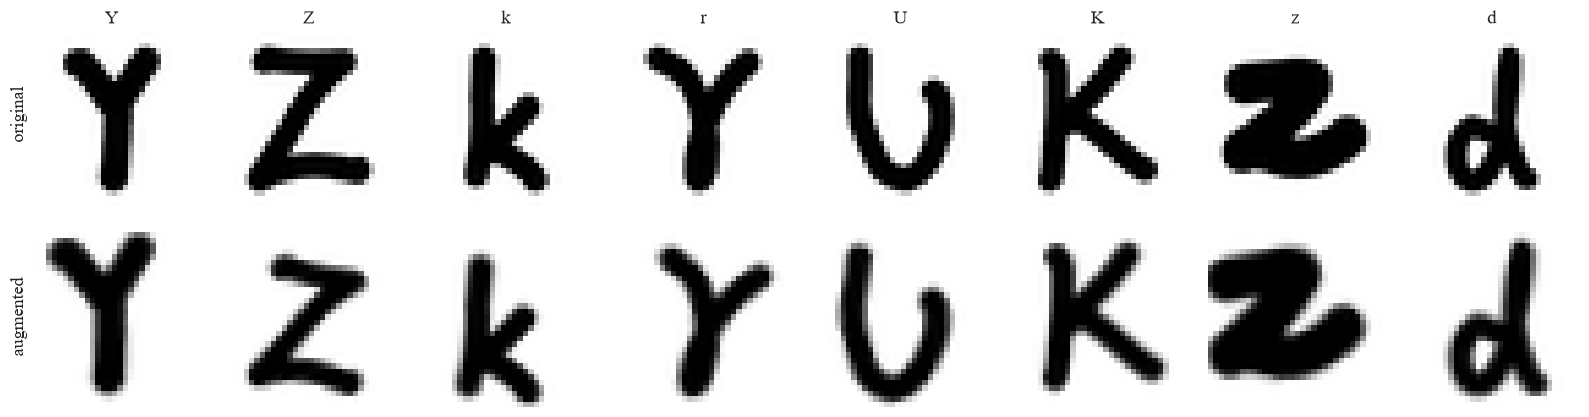


Overfitting mitigation summary (chosen architecture, mean of 4 seeds):
                                                   setting  train_acc  val_acc  val_std    gap
                                             no mitigation     0.9991   0.7793   0.0057 0.2198
                                               dropout 0.4     0.9968   0.7773   0.0060 0.2194
                                         weight decay 1e-3     0.9389   0.7573   0.0159 0.1816
                           dropout 0.4 + weight decay 1e-3     0.9251   0.7710   0.0058 0.1541
                              early stopping (patience 10)     0.9597   0.7759   0.0065 0.1838
                                  augmentation, 100 epochs     0.9602   0.8198   0.0021 0.1404
                                  augmentation, 300 epochs     0.9732   0.8276   0.0029 0.1455
augmentation + dropout 0.4 + weight decay 1e-3, 300 epochs     0.8618   0.7871   0.0096 0.0747

Candidates by mean validation accuracy: {'dropout 0.0, weight decay 0.0'

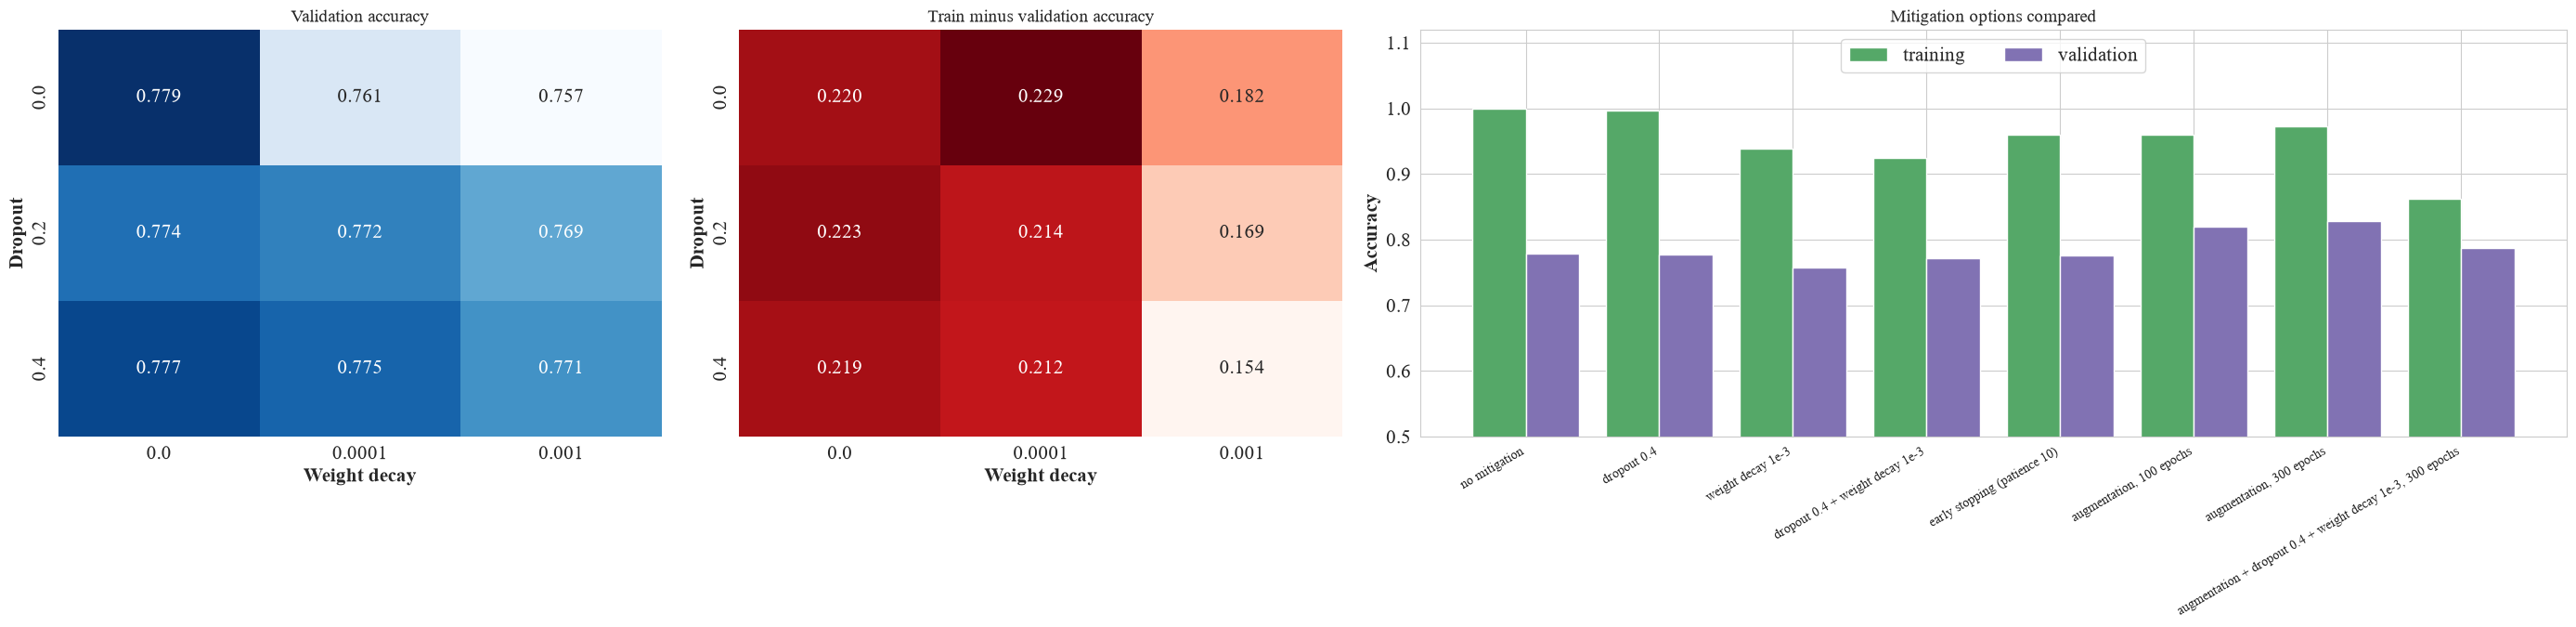

In [22]:
example_idx = np.arange(8) * 7
demo = Xtr_t[torch.tensor(example_idx, device=device)]
torch.manual_seed(RNG)
demo_aug = augment(demo).cpu().numpy()
fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for j in range(8):
    axes[0, j].imshow(demo[j].cpu().numpy().reshape(32, 32), cmap="gray_r")
    axes[1, j].imshow(demo_aug[j].reshape(32, 32), cmap="gray_r")
    axes[0, j].set_title(classes[y_train[example_idx[j]]], fontsize=14)
    for i in range(2):
        axes[i, j].axis("off")
fig.text(0.005, 0.72, "original", rotation=90, va="center", fontsize=13)
fig.text(0.005, 0.28, "augmented", rotation=90, va="center", fontsize=13)
plt.tight_layout()
plt.savefig("figures/12_augmentation_examples.png", dpi=150)
plt.show()
plt.close()

aug_specs = [("augmentation, 100 epochs", dict(augment=True), EPOCHS),
             ("augmentation, 300 epochs", dict(augment=True), 3 * EPOCHS),
             ("augmentation + dropout 0.4 + weight decay 1e-3, 300 epochs", dict(augment=True, dropout=0.4, weight_decay=1e-3), 3 * EPOCHS)]
aug_rows = []
for name, extra, ep in aug_specs:
    cfg = {**arch_cfg, **extra}
    r = multi_seed(cfg, epochs=ep)
    aug_rows.append(dict(setting=name, cfg=cfg, epochs=ep, train_acc=r["train_acc"], val_acc=r["val_acc"], val_std=r["val_std"],
                         gap=r["train_acc"] - r["val_acc"]))

def reg_row(dr, wd):
    return reg_df[(reg_df["dropout"] == dr) & (reg_df["weight_decay"] == wd) & (~reg_df["early_stopping"])].iloc[0]

mitig_rows = []
for dr, wd, name in [(0.0, 0.0, "no mitigation"), (0.4, 0.0, "dropout 0.4"), (0.0, 1e-3, "weight decay 1e-3"), (0.4, 1e-3, "dropout 0.4 + weight decay 1e-3")]:
    row = reg_row(dr, wd)
    mitig_rows.append(dict(setting=name, train_acc=row["train_acc"], val_acc=row["val_acc"], val_std=row["val_std"], gap=row["gap"]))
mitig_rows.append(dict(setting=f"early stopping (patience {PATIENCE})", train_acc=es["train_acc"], val_acc=es["val_acc"], val_std=es["val_std"],
                       gap=es["train_acc"] - es["val_acc"]))
mitig_rows += [{k: r[k] for k in ["setting", "train_acc", "val_acc", "val_std", "gap"]} for r in aug_rows]
mitig_df = pd.DataFrame(mitig_rows)
mitig_df.to_csv("mitigation_summary.csv", index=False)
log(f"\nOverfitting mitigation summary (chosen architecture, mean of {len(SEEDS)} seeds):")
log(mitig_df.round(4).to_string(index=False))

cands = [dict(name=f"dropout {reg_cfg['dropout']}, weight decay {reg_cfg['weight_decay']}", cfg=reg_cfg, patience=None, epochs=EPOCHS, val=float(best_reg["val_acc"])),
         dict(name="early stopping", cfg=reg_cfg, patience=PATIENCE, epochs=EPOCHS, val=float(es["val_acc"]))]
cands += [dict(name=r["setting"], cfg=r["cfg"], patience=None, epochs=r["epochs"], val=float(r["val_acc"])) for r in aug_rows]
chosen = max(cands, key=lambda c: c["val"])
final_cfg, final_patience, final_epochs = chosen["cfg"], chosen["patience"], chosen["epochs"]
log("\nCandidates by mean validation accuracy:", {c["name"]: round(c["val"], 4) for c in cands})
log("Chosen for the final model:", chosen["name"], "| config:", final_cfg, "| epochs:", final_epochs, "| patience:", final_patience)

pivot_val = reg_df[~reg_df["early_stopping"]].pivot(index="dropout", columns="weight_decay", values="val_acc")
pivot_gap = reg_df[~reg_df["early_stopping"]].pivot(index="dropout", columns="weight_decay", values="gap")
fig, axes = plt.subplots(1, 3, figsize=(28, 7), gridspec_kw=dict(width_ratios=[1, 1, 1.9]))
sns.heatmap(pivot_val, annot=True, fmt=".3f", cmap="Blues", ax=axes[0], cbar=False)
axes[0].set_title("Validation accuracy", fontsize=14)
sns.heatmap(pivot_gap, annot=True, fmt=".3f", cmap="Reds", ax=axes[1], cbar=False)
axes[1].set_title("Train minus validation accuracy", fontsize=14)
for ax in axes[:2]:
    ax.set_xlabel("Weight decay")
    ax.set_ylabel("Dropout")
xs = np.arange(len(mitig_df))
axes[2].bar(xs - 0.2, mitig_df["train_acc"], width=0.4, color=SPLIT_COLORS["train"], label="training")
axes[2].bar(xs + 0.2, mitig_df["val_acc"], width=0.4, color=SPLIT_COLORS["val"], label="validation")
axes[2].set_xticks(xs)
axes[2].set_xticklabels(mitig_df["setting"], rotation=30, ha="right", fontsize=10)
axes[2].set_ylim(0.5, 1.12)
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Mitigation options compared", fontsize=14)
axes[2].legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.savefig("figures/06_regularization.png", dpi=150)
plt.show()
plt.close()

## Final MLP and final perceptron on the test set

In [23]:
final_runs = [run_mlp(final_cfg, epochs=final_epochs, seed=s, patience=final_patience) for s in FINAL_SEEDS]
mlp_rows = []
for s, r in zip(FINAL_SEEDS, final_runs):
    p = predict_logits(r["model"], Xte_t).argmax(1)
    mlp_rows.append(dict(seed=s, **score_report(y_test, p), train_acc=r["train_acc"], val_acc=r["val_acc"], seconds=r["seconds"], epochs=r["stopped_at"]))
mlp_seed_df = pd.DataFrame(mlp_rows)
mlp_main = final_runs[0]
mlp_logits = predict_logits(mlp_main["model"], Xte_t)
mlp_pred = mlp_logits.argmax(1)
mlp_probs = torch.softmax(torch.tensor(mlp_logits), dim=1).numpy()
log("Final MLP, test metrics per seed:")
log(mlp_seed_df.round(4).to_string(index=False))

linear_cfg = {**best_cfg, "hidden": []}
lin_runs = [run_mlp(linear_cfg, seed=s) for s in FINAL_SEEDS]
lin_rows = []
for s, r in zip(FINAL_SEEDS, lin_runs):
    p = predict_logits(r["model"], Xte_t).argmax(1)
    lin_rows.append(dict(seed=s, **score_report(y_test, p), train_acc=r["train_acc"], val_acc=r["val_acc"], seconds=r["seconds"], epochs=r["stopped_at"]))
lin_seed_df = pd.DataFrame(lin_rows)
log("\nReference: plain softmax classifier (no hidden layer, same optimizer and loss), test metrics per seed:")
log(lin_seed_df.round(4).to_string(index=False))

plain_cfg = {**arch_cfg}
plain_runs = [run_mlp(plain_cfg, seed=s) for s in FINAL_SEEDS]
plain_rows = []
for s, r in zip(FINAL_SEEDS, plain_runs):
    p = predict_logits(r["model"], Xte_t).argmax(1)
    plain_rows.append(dict(seed=s, **score_report(y_test, p), train_acc=r["train_acc"], val_acc=r["val_acc"], seconds=r["seconds"], epochs=r["stopped_at"]))
plain_seed_df = pd.DataFrame(plain_rows)
log("\nReference: the chosen MLP without augmentation (100 epochs), test metrics per seed:")
log(plain_seed_df.round(4).to_string(index=False))

Xp_train, Xp_val, Xp_test = pla_inputs[PLA_SCALING]
pla_rows = []
pla_models = []
for s in FINAL_SEEDS:
    t0 = time.perf_counter()
    m = Perceptron(Xp_train.shape[1], N_CLASSES, lr=1.0, seed=s)
    hist = m.fit(Xp_train, y_train, PLA_EPOCHS_BEST, Xp_val, y_val)
    sec = time.perf_counter() - t0
    pla_models.append(m)
    pla_rows.append(dict(seed=s, **score_report(y_test, m.predict(Xp_test)), train_acc=1 - hist["train_err"].iloc[-1],
                         val_acc=1 - hist["val_err"].iloc[-1], seconds=sec, epochs=PLA_EPOCHS_BEST))
pla_seed_df = pd.DataFrame(pla_rows)
pla_main = pla_models[0]
pla_scores = pla_main.scores(Xp_test)
pla_pred = pla_scores.argmax(1)
log("\nFinal PLA, test metrics per shuffle seed:")
log(pla_seed_df.round(4).to_string(index=False))

full_pla = Perceptron(Xp_train.shape[1], N_CLASSES, lr=1.0, seed=RNG)
full_hist = full_pla.fit(Xp_train, y_train, PLA_EPOCHS, Xp_val, y_val)
log("PLA trained for all", PLA_EPOCHS, "epochs instead: test accuracy", round(accuracy_score(y_test, full_pla.predict(Xp_test)), 4),
    "| train accuracy", round(1 - full_hist["train_err"].iloc[-1], 4))

Final MLP, test metrics per seed:
 seed  accuracy  precision  recall     f1  train_acc  val_acc  seconds  epochs
   42    0.8379     0.8475  0.8367 0.8344     0.9736   0.8242   2.3516     300
    1    0.8281     0.8393  0.8273 0.8249     0.9732   0.8281   2.2386     300
    2    0.8340     0.8430  0.8342 0.8284     0.9711   0.8320   2.2477     300
    3    0.8223     0.8332  0.8224 0.8207     0.9749   0.8262   2.2222     300
    4    0.8301     0.8415  0.8297 0.8281     0.9715   0.8047   2.1532     300



Reference: plain softmax classifier (no hidden layer, same optimizer and loss), test metrics per seed:
 seed  accuracy  precision  recall     f1  train_acc  val_acc  seconds  epochs
   42    0.7188     0.7294  0.7189 0.7146     0.9983   0.7266   0.3971     100
    1    0.7168     0.7253  0.7173 0.7129     0.9971   0.7305   0.3868     100
    2    0.7129     0.7251  0.7133 0.7092     0.9962   0.7285   0.3694     100
    3    0.7207     0.7343  0.7213 0.7171     0.9983   0.7266   0.3544     100
    4    0.7285     0.7404  0.7285 0.7250     0.9966   0.7285   0.3755     100



Reference: the chosen MLP without augmentation (100 epochs), test metrics per seed:
 seed  accuracy  precision  recall     f1  train_acc  val_acc  seconds  epochs
   42    0.7832     0.7918  0.7827 0.7799     0.9996   0.7773   0.4493     100
    1    0.7734     0.7869  0.7735 0.7705     0.9987   0.7715   0.4965     100
    2    0.7773     0.7861  0.7767 0.7747     0.9987   0.7871   0.5382     100
    3    0.7812     0.7923  0.7809 0.7773     0.9992   0.7812   0.4771     100
    4    0.7773     0.7886  0.7764 0.7736     0.9992   0.7832   0.4498     100



Final PLA, test metrics per shuffle seed:
 seed  accuracy  precision  recall     f1  train_acc  val_acc  seconds  epochs
   42    0.7148     0.7382  0.7142 0.7166     0.9983   0.6973   3.7105      77
    1    0.6934     0.7327  0.6931 0.6957     0.9899   0.6562   3.4624      77
    2    0.6992     0.7192  0.6978 0.6943     0.9950   0.6875   3.6639      77
    3    0.6621     0.7053  0.6615 0.6625     0.9824   0.6562   3.7380      77
    4    0.6953     0.7245  0.6949 0.6965     0.9950   0.6621   3.8227      77


PLA trained for all 100 epochs instead: test accuracy 0.707 | train accuracy 0.9975


In [24]:
roc_pla = roc_micro_macro(y_test, pla_scores)
roc_mlp = roc_micro_macro(y_test, mlp_probs)

ab = pd.DataFrame([
    dict(metric=m, PLA_seed42=pla_seed_df[m].iloc[0], PLA_mean=pla_seed_df[m].mean(), PLA_std=pla_seed_df[m].std(ddof=0),
         Softmax_mean=lin_seed_df[m].mean(), Softmax_std=lin_seed_df[m].std(ddof=0),
         MLPnoaug_mean=plain_seed_df[m].mean(), MLPnoaug_std=plain_seed_df[m].std(ddof=0),
         MLP_seed42=mlp_seed_df[m].iloc[0], MLP_mean=mlp_seed_df[m].mean(), MLP_std=mlp_seed_df[m].std(ddof=0))
    for m in ["accuracy", "precision", "recall", "f1", "train_acc", "val_acc", "seconds"]])
ab.to_csv("ab_comparison.csv", index=False)
log("\nA/B comparison on the test set (5 seeds; seed 42 is the model used in the confusion matrices and ROC curves):")
log(ab.round(4).to_string(index=False))
log("\nROC AUC on the test set (seed 42):")
log("PLA  micro", round(roc_pla["micro"][2], 4), "| macro", round(roc_pla["macro"][2], 4))
log("MLP  micro", round(roc_mlp["micro"][2], 4), "| macro", round(roc_mlp["macro"][2], 4))
log("Parameters: PLA", pla_main.W.size, "| softmax", count_params(lin_runs[0]["model"]), "| MLP", count_params(mlp_main["model"]))
noaug_pred = predict_logits(plain_runs[0]["model"], Xte_t).argmax(1)
log("MLP without augmentation (seed 42) test accuracy by character type:",
    {g: round(float((noaug_pred[class_groups[y_test] == g] == y_test[class_groups[y_test] == g]).mean()), 4) for g in GROUP_ORDER})


A/B comparison on the test set (5 seeds; seed 42 is the model used in the confusion matrices and ROC curves):
   metric  PLA_seed42  PLA_mean  PLA_std  Softmax_mean  Softmax_std  MLPnoaug_mean  MLPnoaug_std  MLP_seed42  MLP_mean  MLP_std
 accuracy      0.7148    0.6930   0.0172        0.7195       0.0052         0.7785        0.0034      0.8379    0.8305   0.0053
precision      0.7382    0.7240   0.0114        0.7309       0.0058         0.7892        0.0025      0.8475    0.8409   0.0047
   recall      0.7142    0.6923   0.0171        0.7198       0.0051         0.7780        0.0033      0.8367    0.8301   0.0051
       f1      0.7166    0.6931   0.0174        0.7158       0.0053         0.7752        0.0032      0.8344    0.8273   0.0045
train_acc      0.9983    0.9921   0.0056        0.9973       0.0009         0.9991        0.0003      0.9736    0.9728   0.0014
  val_acc      0.6973    0.6719   0.0172        0.7281       0.0015         0.7801        0.0053      0.8242    0.8230   

## Training error against epochs

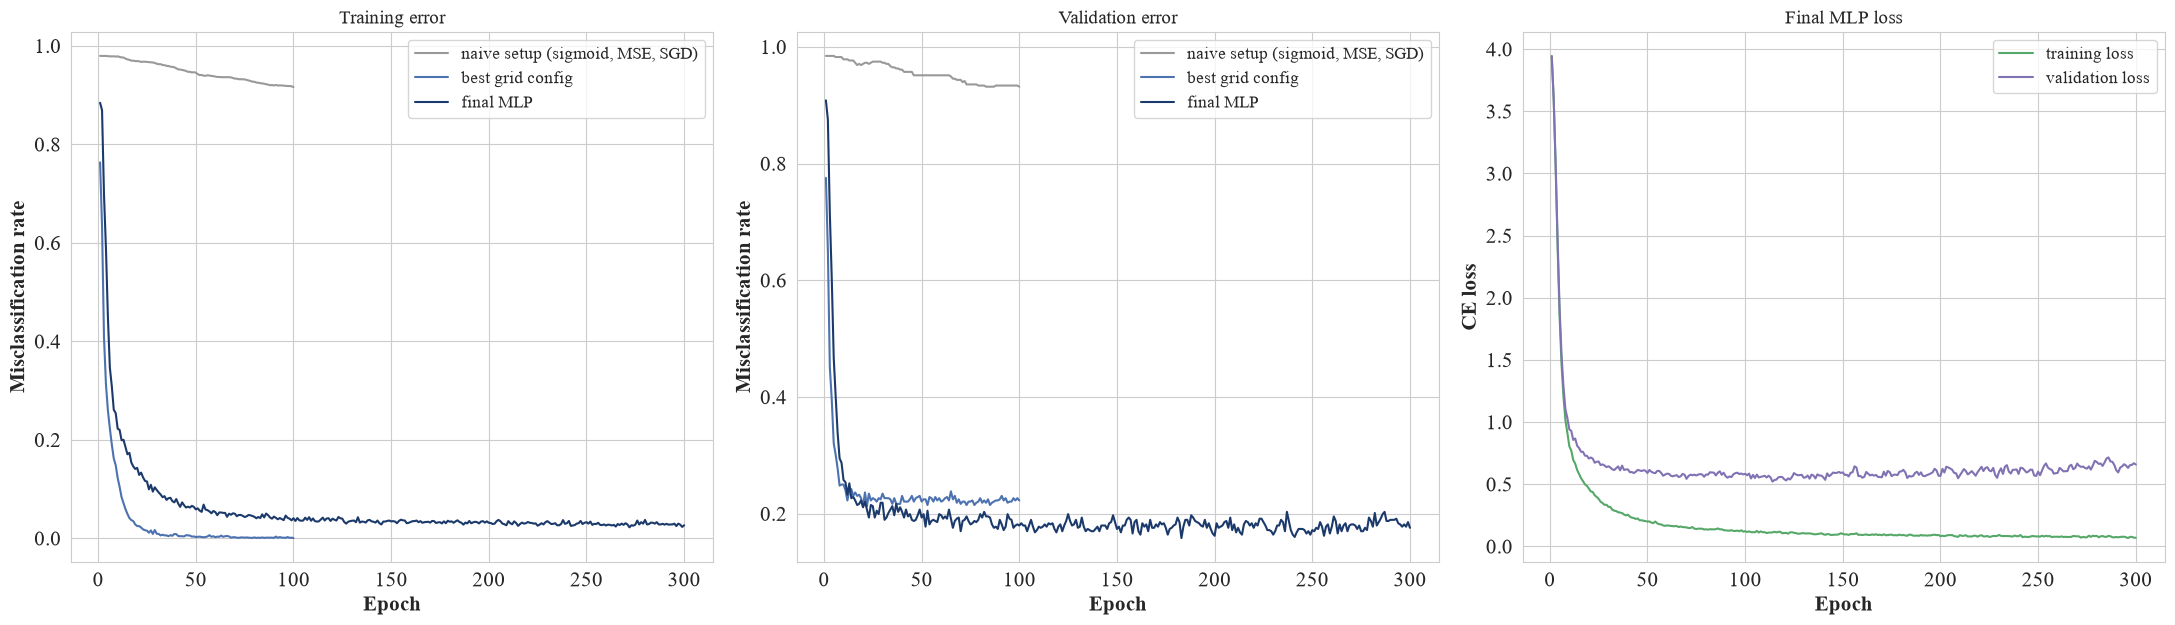

Naive textbook setup (sigmoid, MSE, plain SGD, lr 0.01, batch 32), grid run: val acc 0.0684 | epochs to reach 50% val accuracy: nan
Best grid config: val acc 0.7773 | epochs to 50% val accuracy: 3
Final MLP (seed 42): epochs run 300 | epochs to 50% val accuracy: 5 | epochs to 90% train accuracy: 26


In [25]:
naive_key = ("sigmoid", "MSE", "SGD", 0.01, 32)
naive = grid_curves[naive_key]
grid_best = grid_curves[(best_cfg["activation"], best_cfg["cost"], best_cfg["optimizer"], best_cfg["lr"], best_cfg["batch"])]
fin = mlp_main["hist"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
for h, name, color in [(naive, "naive setup (sigmoid, MSE, SGD)", "#999999"), (grid_best, "best grid config", "#4c72b0"), (fin, "final MLP", "#1b3a6b")]:
    ep = np.arange(1, len(h) + 1)
    axes[0].plot(ep, h[:, 1], color=color, label=name)
    axes[1].plot(ep, h[:, 3], color=color, label=name)
axes[0].set_title("Training error", fontsize=14)
axes[0].set_ylabel("Misclassification rate")
axes[1].set_title("Validation error", fontsize=14)
axes[1].set_ylabel("Misclassification rate")
ep = np.arange(1, len(fin) + 1)
axes[2].plot(ep, fin[:, 0], color=SPLIT_COLORS["train"], label="training loss")
axes[2].plot(ep, fin[:, 2], color=SPLIT_COLORS["val"], label="validation loss")
axes[2].set_title("Final MLP loss", fontsize=14)
axes[2].set_ylabel(f"{final_cfg['cost']} loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/07_mlp_training_curves.png", dpi=150)
plt.show()
plt.close()

log("Naive textbook setup (sigmoid, MSE, plain SGD, lr 0.01, batch 32), grid run: val acc", round(1 - naive[-1, 3], 4),
    "| epochs to reach 50% val accuracy:", epochs_to(naive, 3, 0.5, below=True))
log("Best grid config: val acc", round(1 - grid_best[-1, 3], 4), "| epochs to 50% val accuracy:", epochs_to(grid_best, 3, 0.5, below=True))
log("Final MLP (seed 42): epochs run", len(fin), "| epochs to 50% val accuracy:", epochs_to(fin, 3, 0.5, below=True),
    "| epochs to 90% train accuracy:", epochs_to(fin, 1, 0.10, below=True))

## Confusion matrices

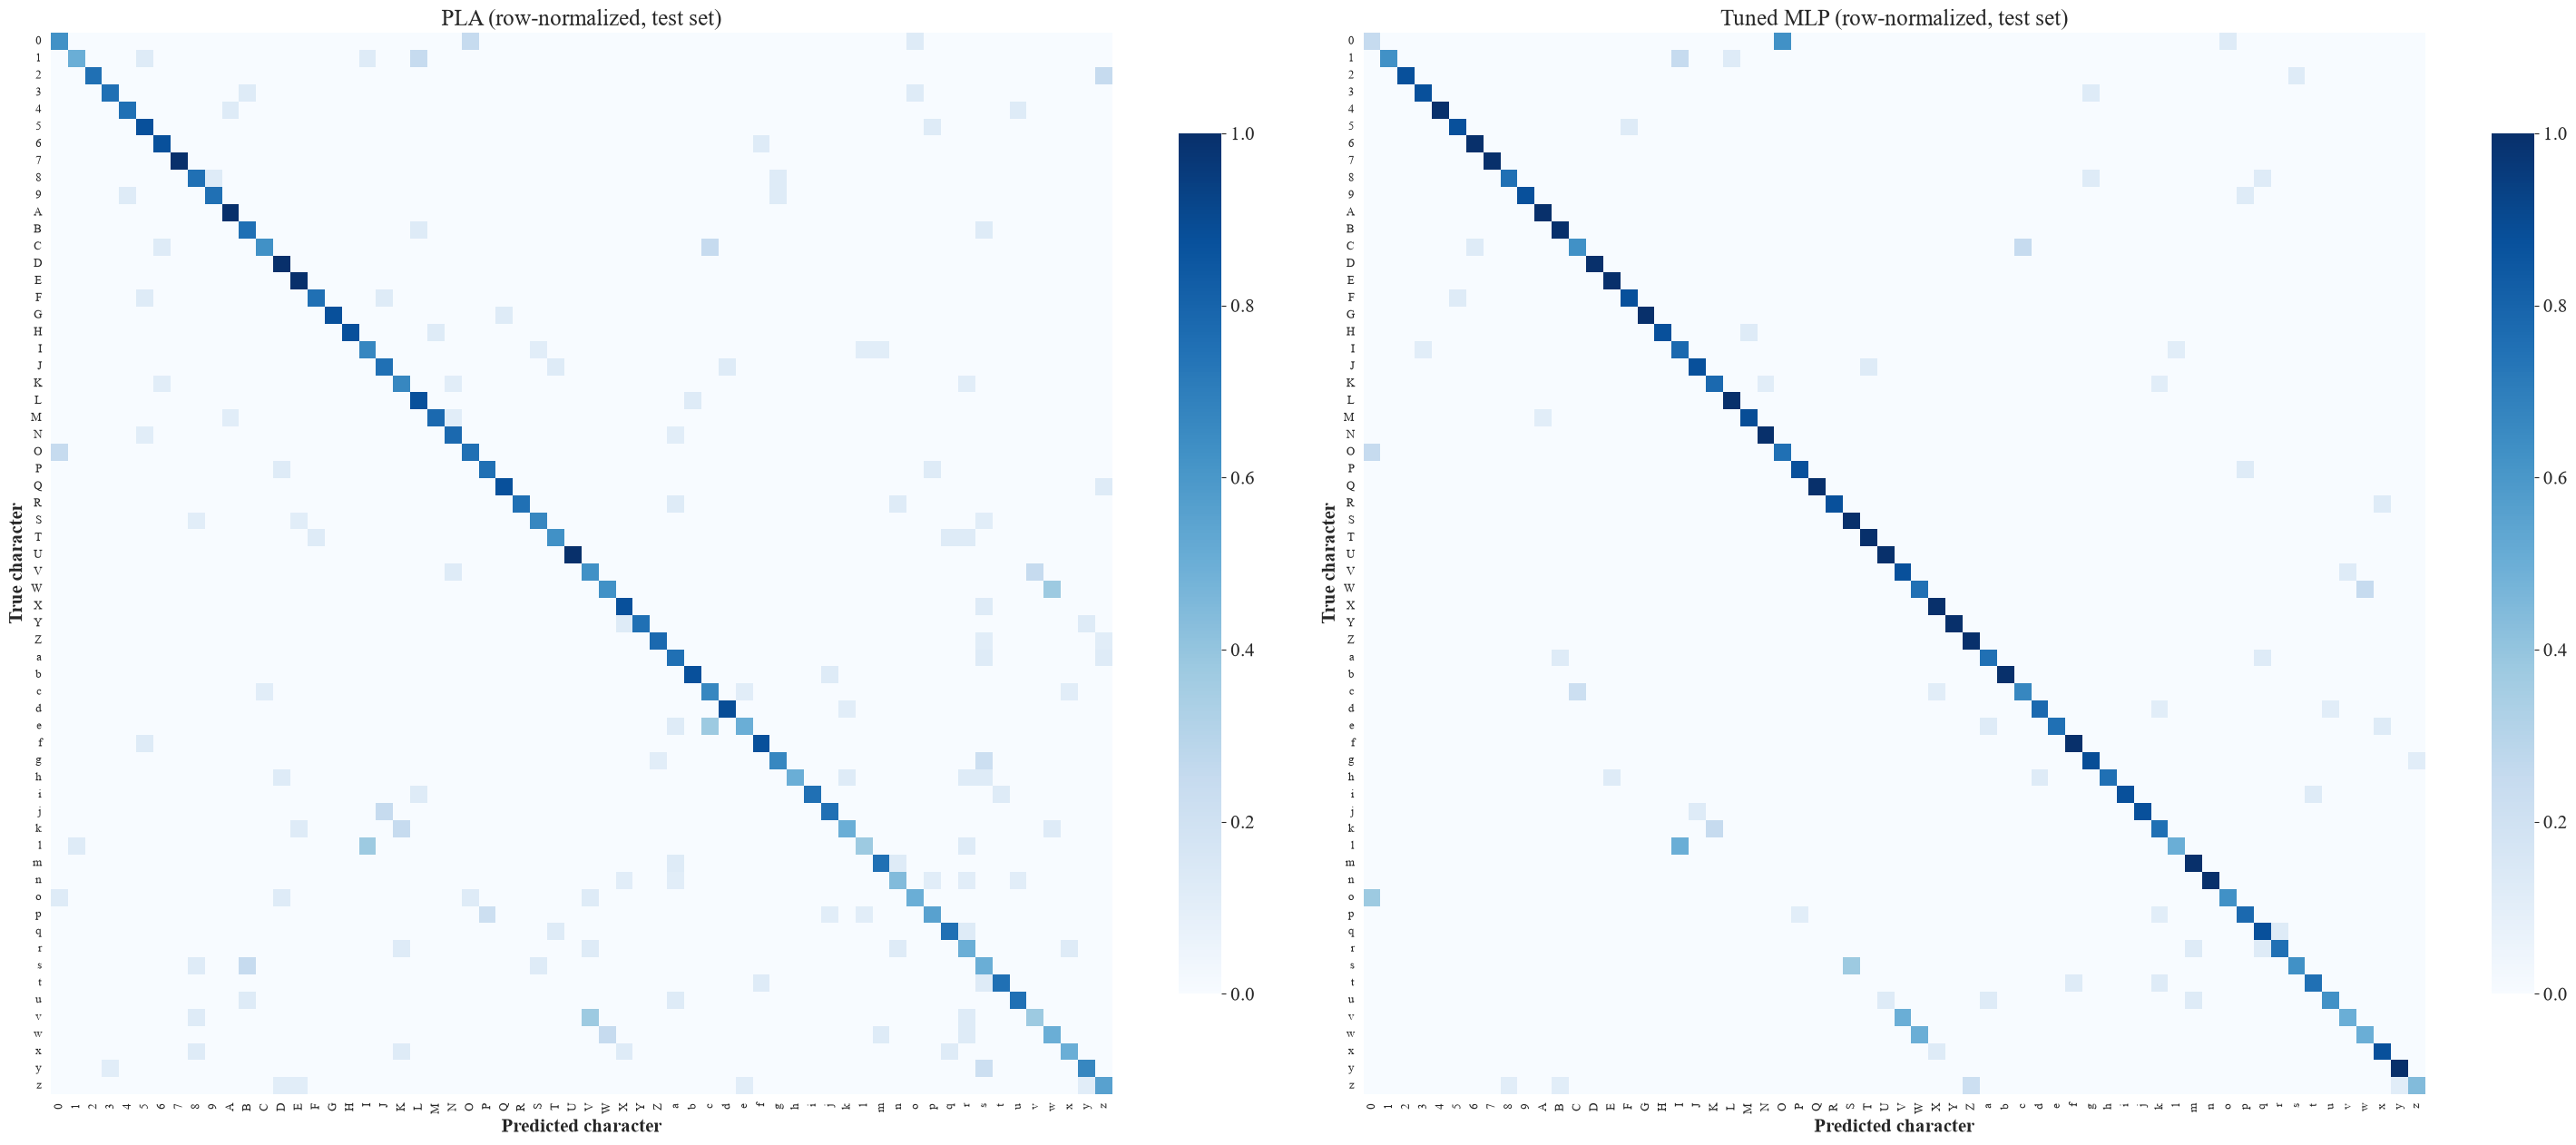

Most frequent MLP confusions on the test set:
true predicted  count  of_true_class
   0         O      5              8
   v         V      4              8
   w         W      4              8
   l         I      4              8
   o         0      3              8
   s         S      3              8
   z         Z      2              9
   k         K      2              8
   c         C      2              9
   W         w      2              8

Most frequent PLA confusions on the test set:
true predicted  count  of_true_class
   l         I      3              8
   W         w      3              8
   e         c      3              8
   v         V      3              8
   k         K      2              8
   g         s      2              9
   0         O      2              8
   s         B      2              8
   V         v      2              8
   y         s      2              9

Test accuracy by character type, and with upper/lower case treated as the same letter:
     

In [26]:
cm_pla = confusion_matrix(y_test, pla_pred, labels=np.arange(N_CLASSES))
cm_mlp = confusion_matrix(y_test, mlp_pred, labels=np.arange(N_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(30, 14))
for ax, cm, title in [(axes[0], cm_pla, "PLA"), (axes[1], cm_mlp, "Tuned MLP")]:
    norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(norm, ax=ax, cmap="Blues", vmin=0, vmax=1, square=True, xticklabels=classes, yticklabels=classes, cbar=True,
                cbar_kws=dict(shrink=0.7))
    ax.set_title(f"{title} (row-normalized, test set)", fontsize=18)
    ax.set_xlabel("Predicted character")
    ax.set_ylabel("True character")
    ax.tick_params(axis="both", labelsize=9)
plt.tight_layout()
plt.savefig("figures/08_confusion_matrices.png", dpi=150)
plt.show()
plt.close()

def top_confusions(cm, k=10):
    off = cm.copy()
    np.fill_diagonal(off, 0)
    order = np.dstack(np.unravel_index(np.argsort(off.ravel())[::-1], off.shape))[0][:k]
    return pd.DataFrame([dict(true=classes[i], predicted=classes[j], count=int(cm[i, j]), of_true_class=int(cm[i].sum())) for i, j in order])

conf_mlp = top_confusions(cm_mlp)
conf_pla = top_confusions(cm_pla)
conf_mlp.to_csv("top_confusions_mlp.csv", index=False)
log("Most frequent MLP confusions on the test set:")
log(conf_mlp.to_string(index=False))
log("\nMost frequent PLA confusions on the test set:")
log(conf_pla.to_string(index=False))

fold = np.array([c.lower() for c in classes])
grp_rows = []
for name, pred in [("PLA", pla_pred), ("MLP no augmentation", noaug_pred), ("MLP", mlp_pred)]:
    row = dict(model=name, overall=(pred == y_test).mean(), case_insensitive=(fold[pred] == fold[y_test]).mean())
    for g in GROUP_ORDER:
        m = class_groups[y_test] == g
        row[g] = (pred[m] == y_test[m]).mean()
    grp_rows.append(row)
grp_df = pd.DataFrame(grp_rows)
grp_df.to_csv("group_accuracy.csv", index=False)
log("\nTest accuracy by character type, and with upper/lower case treated as the same letter:")
log(grp_df.round(4).to_string(index=False))

wrong = np.where(mlp_pred != y_test)[0]
same_letter = int((fold[mlp_pred[wrong]] == fold[y_test[wrong]]).sum())
log(f"MLP test errors: {len(wrong)}; of these, {same_letter} are the same letter in the other case ({same_letter / len(wrong):.1%})")

## ROC curves

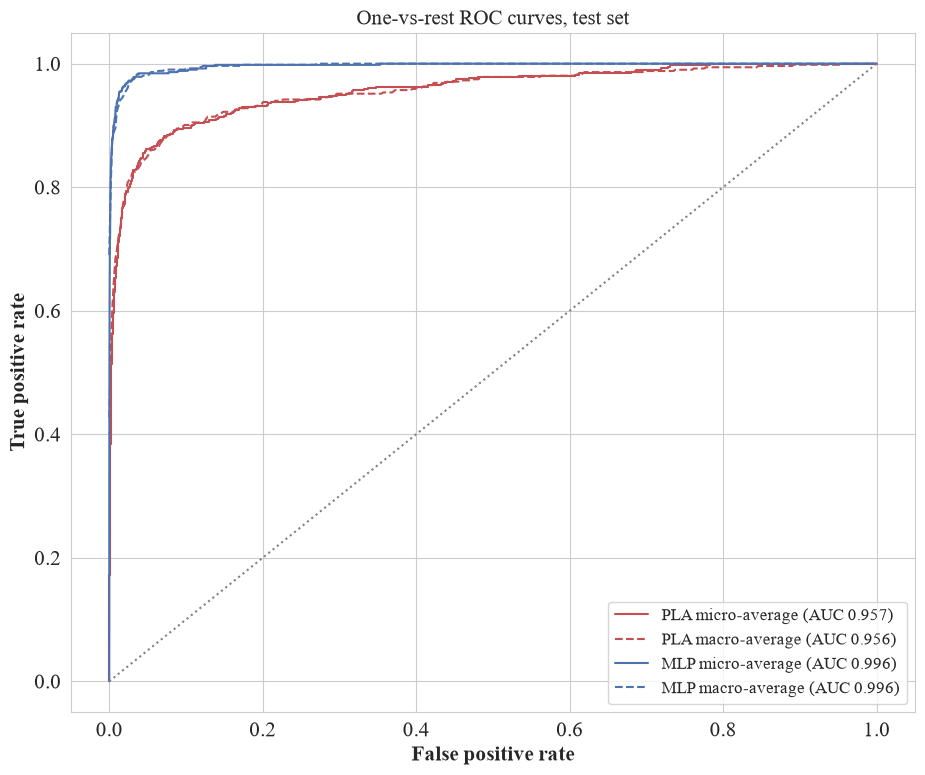

In [27]:
fig, ax = plt.subplots(figsize=(9.5, 8))
for name, r in [("PLA", roc_pla), ("MLP", roc_mlp)]:
    ax.plot(r["micro"][0], r["micro"][1], color=MODEL_COLORS[name], linestyle="-", label=f"{name} micro-average (AUC {r['micro'][2]:.3f})")
    ax.plot(r["macro"][0], r["macro"][1], color=MODEL_COLORS[name], linestyle="--", label=f"{name} macro-average (AUC {r['macro'][2]:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle=":")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("One-vs-rest ROC curves, test set", fontsize=15)
ax.legend(fontsize=12, loc="lower right")
plt.tight_layout()
plt.savefig("figures/09_roc_curves.png", dpi=150)
plt.show()
plt.close()

## PLA vs MLP side by side

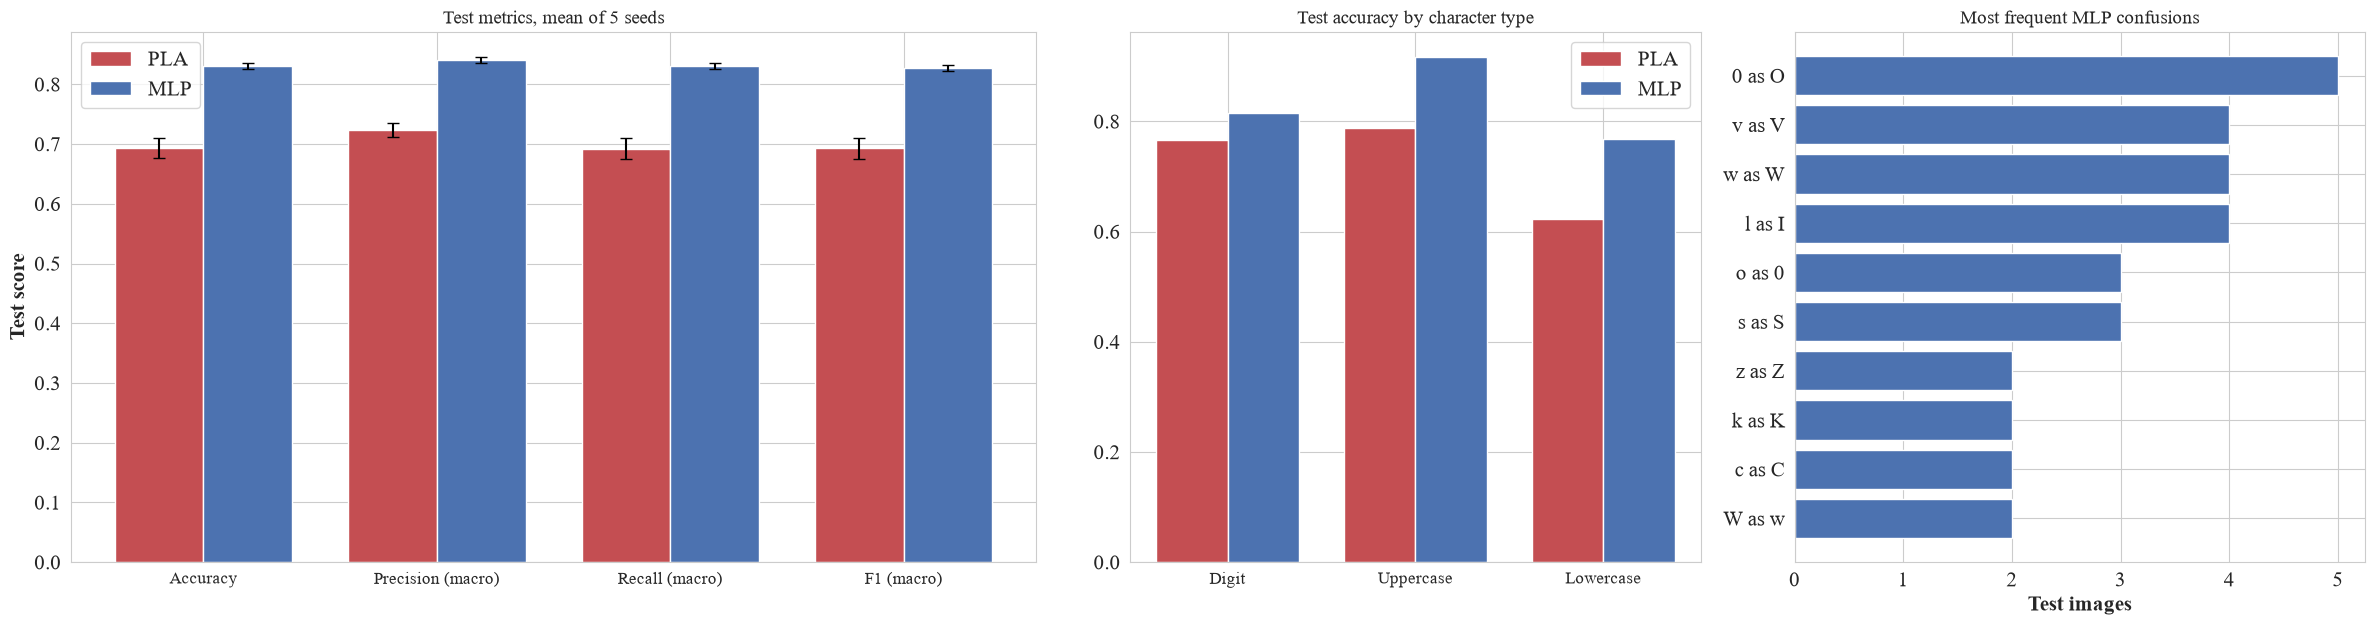

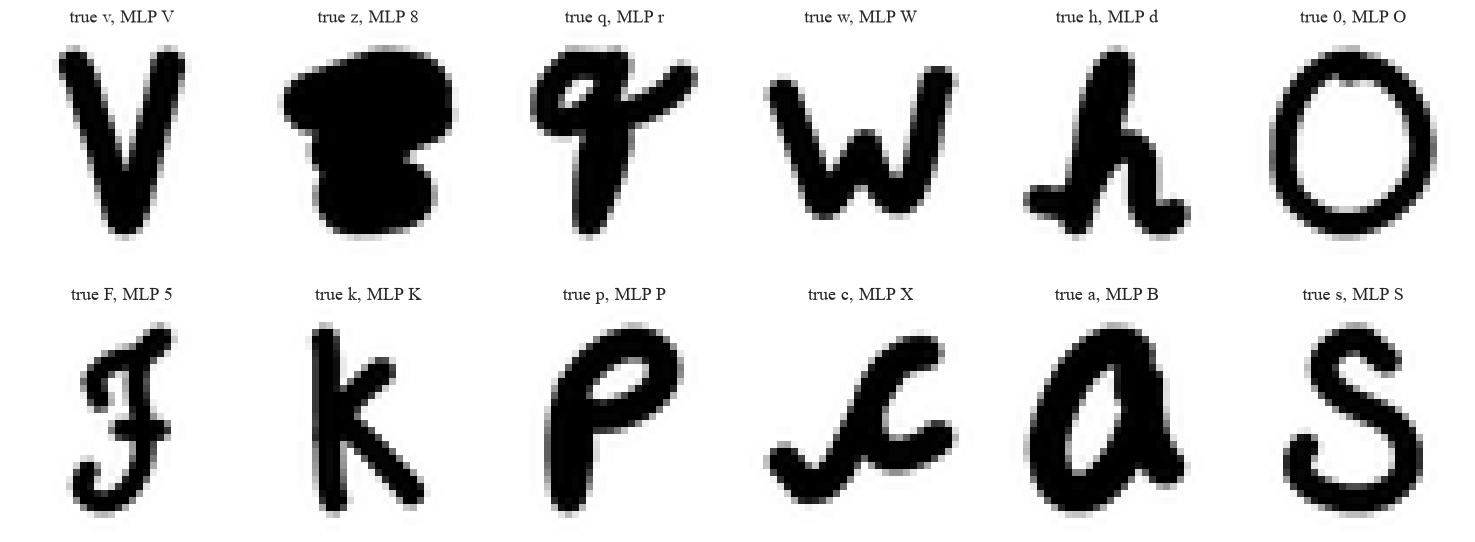

In [28]:
metric_names = ["accuracy", "precision", "recall", "f1"]
fig, axes = plt.subplots(1, 3, figsize=(24, 6.5), gridspec_kw=dict(width_ratios=[2.2, 1.3, 1.3]))
xs = np.arange(len(metric_names))
for k, (name, df) in enumerate([("PLA", pla_seed_df), ("MLP", mlp_seed_df)]):
    axes[0].bar(xs + (k - 0.5) * 0.38, [df[m].mean() for m in metric_names], width=0.38, yerr=[df[m].std(ddof=0) for m in metric_names],
                capsize=4, color=MODEL_COLORS[name], label=name)
axes[0].set_xticks(xs)
axes[0].set_xticklabels(["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"], fontsize=12)
axes[0].set_ylabel("Test score")
axes[0].set_title("Test metrics, mean of 5 seeds", fontsize=14)
axes[0].legend()

xg = np.arange(len(GROUP_ORDER))
for k, name in enumerate(["PLA", "MLP"]):
    row = grp_df[grp_df["model"] == name].iloc[0]
    axes[1].bar(xg + (k - 0.5) * 0.38, [row[g] for g in GROUP_ORDER], width=0.38, color=MODEL_COLORS[name], label=name)
axes[1].set_xticks(xg)
axes[1].set_xticklabels(GROUP_ORDER, fontsize=12)
axes[1].set_title("Test accuracy by character type", fontsize=14)
axes[1].legend()

axes[2].barh([f"{r.true} as {r.predicted}" for r in conf_mlp.itertuples()][::-1], conf_mlp["count"][::-1], color=MODEL_COLORS["MLP"])
axes[2].set_title("Most frequent MLP confusions", fontsize=14)
axes[2].set_xlabel("Test images")
plt.tight_layout()
plt.savefig("figures/10_ab_comparison.png", dpi=150)
plt.show()
plt.close()

first_wrong = wrong[:12]
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for ax, i in zip(axes.ravel(), first_wrong):
    ax.imshow(X_img[idx_test[i]], cmap="gray_r")
    ax.set_title(f"true {classes[y_test[i]]}, MLP {classes[mlp_pred[i]]}", fontsize=13)
    ax.axis("off")
plt.tight_layout()
plt.savefig("figures/11_mlp_errors.png", dpi=150)
plt.show()
plt.close()

## Saving the summary

In [29]:
log("\nEnvironment: numpy", np.__version__, "| scikit-learn", sklearn.__version__, "| torch", torch.__version__, "|", torch.cuda.get_device_name(0) if device.type == "cuda" else "cpu")
with open("results_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(summary))
print("saved results_summary.txt with", len(summary), "lines")


Environment: numpy 2.5.1 | scikit-learn 1.9.0 | torch 2.11.0+cu128 | NVIDIA GeForce RTX 5060 Laptop GPU
saved results_summary.txt with 73 lines
